## Exemple d'utilisation de TCA (unidimensionnel)

Cette section illustre une utilisation complète du package `trajectoryclusteringanalysis` dans le cas d'un jeu de données unidimensionnel, ici on utilise `unidimisional_data`. 

Ce jeu de données suit l'évolution clinique de patients sur plusieurs mois.
La variable d'intérêt est le **`care_status`**, qui représente l'état du patient à un mois ($t$) donné :
* **`D` : Diagnostiqué**
* **`C` : Consultation**
* **`T` : Traitement**
* **`S` : Infection contrôlée**

Pour chaque patient, nous disposons de ces variables (j'ai choisi cette interprétation)
* `age` (catégoriel) (1.0: Jeune, 2.0: Adulte, 3.0: Senior)
* `sex` (0: Homme, 1: Femme).
* `education` (niveau d'études) (1.0: Basse, 2.0: Moyenne, 3.0: Haute).
* `wealth` (indice de richesse) (1.0: Pauvre, 2.0: Moyen, 3.0: Riche).
* `distance_clinic` (proximité géographique avec le centre de soins) (1.0: Proche, 2.0: Éloigné).


> **Objectif** : Regrouper les patients ayant des parcours de soins similaires et ajouter des fonctions qui permettent d'interpréter si des facteurs comme la précarité (`wealth`) ou l'éloignement (`distance_clinic`) influencent la probabilité d'atteindre rapidement l'état de succès (`S`).

1. Import des fonctions et librairies utilisées ainsi que du jeu de données
2. Préparation du jeu de données et initialisation du TCA
3. Calcul des `distance_matrix` pour différentes distances (Hamming, Levenshtein, Optimal-Matching, ...)
4. Clustering avec différentes méthodes (CAH, K-means, K-medoids)
5. Ajouts

# 1. Imports

In [85]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree
from lifelines import KaplanMeierFitter
import matplotlib.gridspec as gridspec


project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\src


Fonctions

In [2]:
# Passage de format long à large
def long_to_wide_format(df, id_col, time_col, value_col, prefix="time_", static_cols=None, shift_time=False, sample_frac=0.1, random_state=42):
    """
    Transforme un DataFrame du format long au format large.

    Paramètres:
    -----------
    df : pd.DataFrame
        Le DataFrame d'origine au format long.
    id_col : str
        Le nom de la colonne identifiant les patients/individus (ex: 'id_patient').
    time_col : str
        Le nom de la colonne temporelle (ex: 'month', 'time').
    value_col : str
        Le nom de la colonne contenant les états/valeurs (ex: 'care_status', 'etat').
    prefix : str, optionnel
        Le préfixe à ajouter aux nouvelles colonnes temporelles créées (défaut: "time_").
    static_cols : list of str, optionnel
        Les ariables cliniques à extraire
        Les noms des colonnes statiques à conserver dans le DataFrame pivoté.
    shift_time : bool, optionnel
        Si True, ajoute +1 à la valeur de la colonne temporelle lors du renommage 
        (utile si les temps commencent à 0 dans les données mais qu'on souhaite afficher M1, M2...).
    sample_frac : float, optionnel
        Fraction de l'échantillon d'individus à conserver (entre 0.0 et 1.0). 
        Défaut: 0.1 (conserve 10%).
    random_state : int, optionnel
        Graine aléatoire (défaut: 42).
        
    Retourne:
    ---------
    pd.DataFrame
        Le DataFrame pivoté au format wide, avec l'identifiant en première colonne
        suivi des colonnes temporelles nommées avec le préfixe
    """
    
    # Tirage au sort des identifiants
    # On isole les IDs uniques
    unique_ids = df[id_col].unique()
    
    # Calcul du nombre de patients à garder
    n_samples = max(1, int(len(unique_ids) * sample_frac)) 
    
    rng = np.random.default_rng(random_state)
    sampled_ids = rng.choice(unique_ids, size=n_samples, replace=False)
    
    # On filtre le DataFrame long pour ne garder que les patients tirés au sort
    df_sampled = df[df[id_col].isin(sampled_ids)]
    
    # On garde les colonnes statiques
    df_clinical = None
    if static_cols is not None:
        cols_to_keep = [id_col] + static_cols
        df_clinical = df_sampled[cols_to_keep].drop_duplicates(subset=[id_col])
        
        df_clinical = df_clinical.drop(columns=[id_col]).reset_index(drop=True)
    
    # Pivot
    pivoted_data = df_sampled.pivot(index=id_col, columns=time_col, values=value_col)
    
    if shift_time:
        pivoted_data.columns = [f"{prefix}{int(col) + 1}" for col in pivoted_data.columns]
    else:
        pivoted_data.columns = [f"{prefix}{col}" for col in pivoted_data.columns]
        
    # Reset index à la toute fin pour repasser l'id_col en colonne normale
    if static_cols is not None:
        return pivoted_data.reset_index(), df_clinical
    else:
        return pivoted_data.reset_index()
    

# Visualisation de la matrice de coûts
def plot_cost_matrix(cost_matrix, ax=None, title="Matrice de coûts de substitution", cmap="YlOrRd", annot_fmt=".2f"):
    """
    Affiche la matrice de coûts sous forme de carte de chaleur (Heatmap).
    
    Paramètres:
    -----------
    cost_matrix : pd.DataFrame
        La matrice des coûts de substitution.
    ax : matplotlib.axes.Axes, optionnel
        L'axe sur lequel tracer le graphique. Si None, une nouvelle figure est créée.
    title : str, optionnel
        Le titre du graphique.
    cmap : str ou matplotlib.colors.Colormap, optionnel
        La palette de couleurs utilisée pour la heatmap (défaut : "YlOrRd").
    annot_fmt : str, optionnel
        Le formatage des nombres affichés dans les cases (défaut : ".2f" pour 2 décimales).
        
    Retourne:
    ---------
    matplotlib.axes.Axes
        L'axe contenant le graphique.
    """
    
    # Si on n'a pas fourni de case spécifique (ax), on en crée une.
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
        is_autonomous = True
    else:
        is_autonomous = False
        
    # Création de la Heatmap
    sns.heatmap(
        cost_matrix, 
        annot=True, 
        cmap=cmap, 
        cbar_kws={'label': 'Coût de substitution'},
        fmt=annot_fmt,
        linewidths=0.5, 
        linecolor='gray',
        ax=ax
    )
    
    ax.set_title(title, pad=15, fontsize=14, fontweight='bold')
    ax.set_xlabel("État d'arrivée", fontsize=12)
    ax.set_ylabel("État de départ", fontsize=12)
    
    # Rotation des étiquettes (ticks) pour la lisibilité
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)
    
    if is_autonomous:
        plt.tight_layout()
        plt.show()
        
    return ax


In [ ]:
df = pd.read_csv(project_root / "data" / "unidimensional_data.csv")
df.head()

,id,month,care_status,sex,age,education,wealth,distance_clinic
0,3,0.0,D,1.0,1.0,2.0,2.0,1.0
1,3,1.0,D,1.0,1.0,2.0,2.0,1.0
2,3,2.0,D,1.0,1.0,2.0,2.0,1.0
3,3,3.0,D,1.0,1.0,2.0,2.0,1.0
4,3,4.0,D,1.0,1.0,2.0,2.0,1.0


# 2. Préparation du jeu de données et initialisation du TCA

On transforme les données pour obtenir une matrice individus-mois. Ce format ne conserve que l'évolution temporelle en supprimant les autres variables afin de simplifier l'analyse.

In [4]:
colonnes_stats = ['sex', 'age', 'education', 'wealth', 'distance_clinic']

wide_df, col_stats = long_to_wide_format(df, id_col="id", time_col="month", value_col="care_status", prefix="month_", static_cols = colonnes_stats, shift_time=True, sample_frac=0.1, random_state=42)

label_var = {
    'sex': {0.0: 'Homme', 1.0: 'Femme'},
    'distance_clinic': {1.0: 'Proche', 2.0: 'Éloigné'},
    'wealth': {1.0: 'Pauvre', 2.0: 'Moyen', 3.0: 'Riche'},
    'education': {1.0: 'Basse', 2.0: 'Moyenne', 3.0: 'Haute'},
    'age': {1.0: 'Jeune', 2.0: 'Adulte', 3.0: 'Senior'}
}

wide_df.head()

,id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,...,month_40,month_41,month_42,month_43,month_44,month_45,month_46,month_47,month_48,month_49
0,84,D,C,C,C,C,D,D,D,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,196,D,D,D,D,D,D,D,D,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,213,D,C,C,C,C,C,C,C,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,222,D,D,D,D,C,T,T,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,282,D,C,C,C,C,C,C,C,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On peut maintenant créer une instance de TCA pour l'analyse unidimensionelle :

In [74]:
tca = TCA(data=wide_df,
              index_col='id',
              time_col=None,  # Pas utilisé dans l'analyse unidimensionnelle
              event_col=None,  # Pas utilisé dans l'analyse unidimensionnelle
              alphabet=['D', 'C', 'T', 'S'],
              states=["diagnostiqué", "en soins", "sous traitement", "inf. contrôlée"], 
              mode='unidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The unidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (292, 50)
state coding:
   alphabet            label  label encoded
0        D     diagnostiqué              1
1        C         en soins              2
2        T  sous traitement              3
3        S   inf. contrôlée              4


# 3. Calcul des distances

On calcule d'abord nos matrice de coûts (erreur pour la matrice pour les fréquences)

In [73]:
# Méthode 1 : Matrice de coût constante
cost_matrix_constant = tca.compute_substitution_cost_matrix()
cost_matrix_constant

,D,C,T,S
D,0.0,2.0,2.0,2.0
C,2.0,0.0,2.0,2.0
T,2.0,2.0,0.0,2.0
S,2.0,2.0,2.0,0.0


In [7]:
#Méthode 2 : Matrice de coût basée sur les fréquences d'observation
cost_matrix_frequency = tca.compute_substitution_cost_matrix(method='frequency')
cost_matrix_frequency

,D,C,T,S
D,0.000000,1.877628,1.974524,1.988967
C,1.877628,0.000000,1.853099,1.948162
T,1.974524,1.853099,0.000000,1.841050
S,1.988967,1.948162,1.841050,0.000000


In [8]:
# Méthode 3 : Matrice de coût customisée
couts = {
    'D:D': 0.0, 'D:C': 1.5, 'D:T': 2.0, 'D:S': 3.0,
    'C:D': 1.5, 'C:C': 0.0, 'C:T': 1.0, 'C:S': 2.5,
    'T:D': 2.0, 'T:C': 1.0, 'T:T': 0.0, 'T:S': 1.0,
    'S:D': 3.0, 'S:C': 2.5, 'S:T': 1.0, 'S:S': 0.0
}
cost_matrix_custom = tca.compute_substitution_cost_matrix(method='custom', custom_costs=couts)
cost_matrix_custom

,D,C,T,S
D,0.0,1.5,2.0,3.0
C,1.5,0.0,1.0,2.5
T,2.0,1.0,0.0,1.0
S,3.0,2.5,1.0,0.0


On peut visualiser ces matrices de coûts sous forme de carte de chaleur, plus on s'approche du rouge, plus le coût est élevé, plus on s'approche du jaune, plus le coût est faible.

Affichage des Heatmaps :


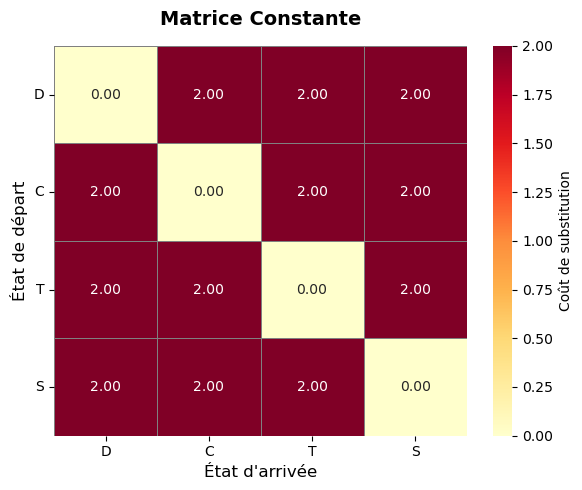

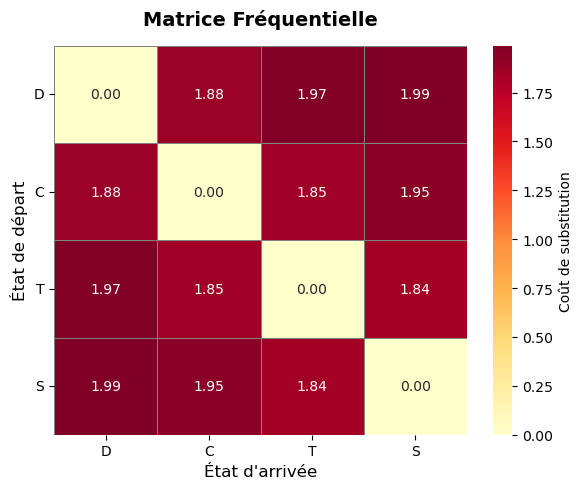

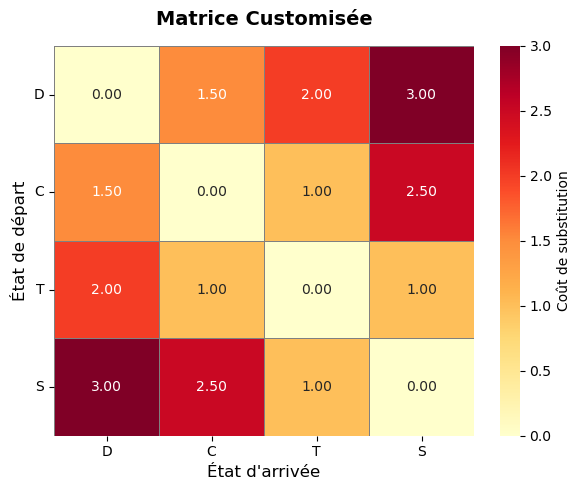

<Axes: title={'center': 'Matrice Customisée'}, xlabel="État d'arrivée", ylabel='État de départ'>

In [ ]:
print("Affichage des Heatmaps :")
plot_cost_matrix(cost_matrix_constant, title="Matrice Constante")
plot_cost_matrix(cost_matrix_frequency, title="Matrice Fréquentielle")
plot_cost_matrix(cost_matrix_custom, title="Matrice Customisée")

## 3.1. Distance de Hamming

In [10]:
distance_matrix_ham = tca.compute_distance_matrix(tca.data,metric='hamming', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Hamming):\n",distance_matrix_ham)

INFO:root:Calculating distance matrix using metric: hamming...
INFO:root:Time taken for computation: 0.01 seconds


Distance matrix (Hamming):
 [[0.         0.83673469 0.87755102 ... 0.97959184 0.85714286 0.97959184]
 [0.83673469 0.         0.95918367 ... 0.97959184 0.89795918 0.95918367]
 [0.87755102 0.95918367 0.         ... 0.97959184 0.89795918 0.97959184]
 ...
 [0.97959184 0.97959184 0.97959184 ... 0.         0.97959184 0.97959184]
 [0.85714286 0.89795918 0.89795918 ... 0.97959184 0.         0.97959184]
 [0.97959184 0.95918367 0.97959184 ... 0.97959184 0.97959184 0.        ]]


## 3.2. Distance de Levenshtein

In [11]:
distance_matrix_lev = tca.compute_distance_matrix(tca.data,metric='levenshtein', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Levenshtein):\n",distance_matrix_lev)

INFO:root:Calculating distance matrix using metric: levenshtein...
100%|██████████| 292/292 [00:00<00:00, 523.65it/s]
INFO:root:Time taken for computation: 0.57 seconds


Distance matrix (Levenshtein):
 [[ 0.  5.  6. ... 11. 21. 10.]
 [ 5.  0. 11. ... 12. 23. 11.]
 [ 6. 11.  0. ...  9. 21.  8.]
 ...
 [11. 12.  9. ...  0. 27.  1.]
 [21. 23. 21. ... 27.  0. 26.]
 [10. 11.  8. ...  1. 26.  0.]]


## 3.3. Distance Optimal Matching

In [12]:
distance_matrix_OM = tca.compute_distance_matrix(tca.data,metric='optimal_matching', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Optimal Matching):\n",distance_matrix_OM)

INFO:root:Calculating distance matrix using metric: optimal_matching...


Calculated indel cost: 0.9944834080063996 (from max sub_cost: 1.9889668160127991)
substitution cost matrix: 
           D         C         T         S
D  0.000000  1.877628  1.974524  1.988967
C  1.877628  0.000000  1.853099  1.948162
T  1.974524  1.853099  0.000000  1.841050
S  1.988967  1.948162  1.841050  0.000000


100%|██████████| 292/292 [00:24<00:00, 12.11it/s]
INFO:root:Time taken for computation: 24.12 seconds


Distance matrix (Optimal Matching):
 [[0.         0.65423047 0.79162329 ... 0.91160979 0.84048521 0.82873617]
 [0.65423047 0.         1.38495966 ... 0.91798468 1.07614528 0.84148596]
 [0.79162329 1.38495966 0.         ... 0.89503507 0.84270952 0.79558673]
 ...
 [0.91160979 0.91798468 0.89503507 ... 0.         0.95896614 0.4972417 ]
 [0.84048521 1.07614528 0.84270952 ... 0.95896614 0.         0.92344888]
 [0.82873617 0.84148596 0.79558673 ... 0.4972417  0.92344888 0.        ]]


## 3.4. Distance Dynamic Time Warping (DTW)

In [13]:
distance_matrix_dtw = tca.compute_distance_matrix(tca.data,metric='dtw')
print("Distance matrix (DTW):\n",distance_matrix_dtw)

INFO:root:Calculating distance matrix using metric: dtw...
100%|██████████| 292/292 [00:22<00:00, 13.24it/s]
INFO:root:Time taken for computation: 22.06 seconds


Distance matrix (DTW):
 [[0.         0.15384615 0.         ... 0.16666667 0.35174492 0.16666667]
 [0.15384615 0.         0.21757132 ... 0.         0.42857143 0.        ]
 [0.         0.21757132 0.         ... 0.28284271 0.29233403 0.28284271]
 ...
 [0.16666667 0.         0.28284271 ... 0.         0.42857143 0.        ]
 [0.35174492 0.42857143 0.29233403 ... 0.42857143 0.         0.42857143]
 [0.16666667 0.         0.28284271 ... 0.         0.42857143 0.        ]]


## 3.5. Distance Global Alignment Kernel (GAK)

In [14]:
distance_matrix_gak = tca.compute_distance_matrix(tca.data,metric='gak')
print("Distance matrix (GAK):\n",distance_matrix_gak)

INFO:root:Calculating distance matrix using metric: gak...
100%|██████████| 292/292 [00:20<00:00, 13.96it/s]
INFO:root:Time taken for computation: 20.92 seconds


Distance matrix (GAK):
 [[0.00000000e+00 1.72997961e-03 1.08383042e-03 ... 1.32627766e-06
  2.87735690e-33 1.58819896e-05]
 [1.72997961e-03 0.00000000e+00 1.67724702e-06 ... 4.84958760e-06
  1.53063409e-41 6.99977676e-05]
 [1.08383042e-03 1.67724702e-06 0.00000000e+00 ... 2.36248590e-07
  1.91309445e-24 1.97533666e-06]
 ...
 [1.32627766e-06 4.84958760e-06 2.36248590e-07 ... 0.00000000e+00
  8.87011222e-47 2.88675135e-01]
 [2.87735690e-33 1.53063409e-41 1.91309445e-24 ... 8.87011222e-47
  0.00000000e+00 1.78767123e-45]
 [1.58819896e-05 6.99977676e-05 1.97533666e-06 ... 2.88675135e-01
  1.78767123e-45 0.00000000e+00]]


# 4. Clustering

## 4.1. Distance de Hamming

### 4.1.1. CAH
On fait d'abord une classification Ascendante Hiérarchique pour savoir quel nombre de clusters serait le mieux 

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


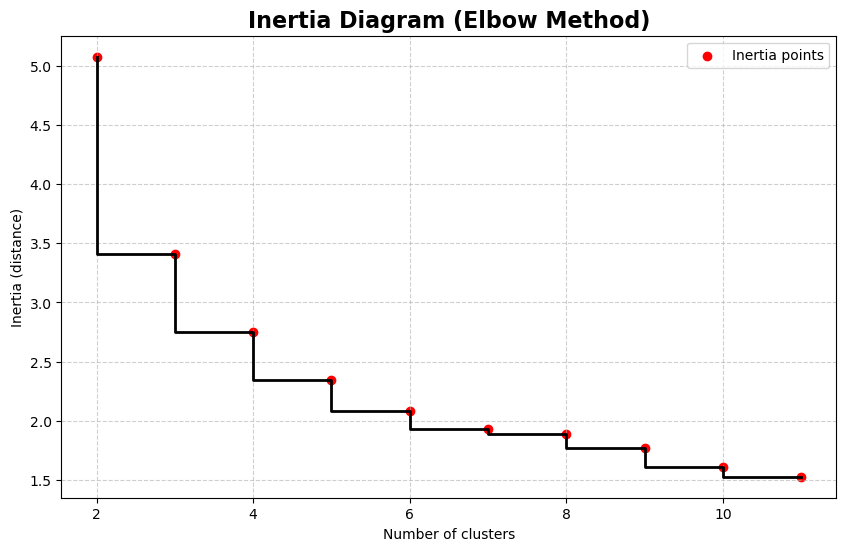

In [15]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_ham = tca.hierarchical_clustering(distance_matrix_ham)
#tca.plot_dendrogram(linkage_matrix_ham)
#tca.plot_clustermap(tca.data,linkage_matrix_ham)
tca.plot_inertia(linkage_matrix_ham)

On teste pour 3 clusters.

### 4.1.2. K-medoids

In [16]:
kmedoids_labels_ham, medoid_indices_ham, inertia_med_ham = tca.kmedoids_clustering(distance_matrix_ham, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Hamming) :", np.unique(kmedoids_labels_ham))
print("medoid_indices (Hamming) :", medoid_indices_ham)
print("inertia (Hamming) :", inertia_med_ham)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Hamming) : [1 2 3]
medoid_indices (Hamming) : [ 11 124 156]
inertia (Hamming) : 210.61224489795936


### 4.1.3. Heatmaps 
Actuellement, la fonction `plot_cluster_heatmaps` (dans le module plotting.py) crée une nouvelle figure à chaque appel. Il serait interessant de la modifier pour qu'elle accepte un argument ax (un axe Matplotlib). Cela permettra d'afficher plusieurs heatmaps sur une seule et même grille (subplots) pour la comparaison des modèles.

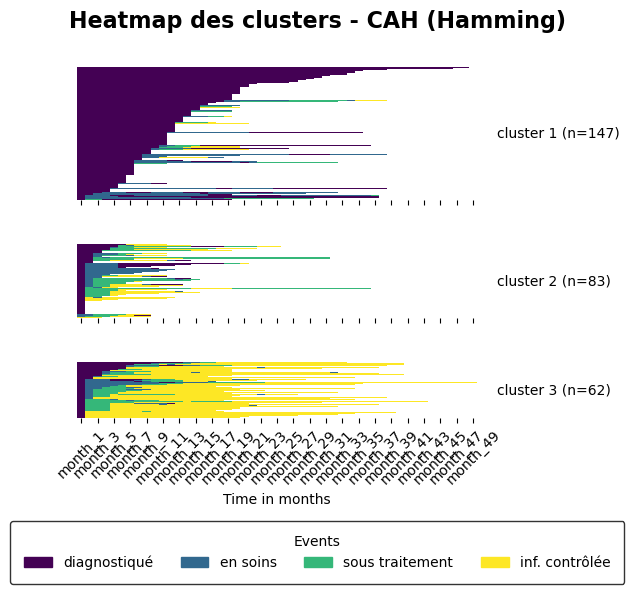

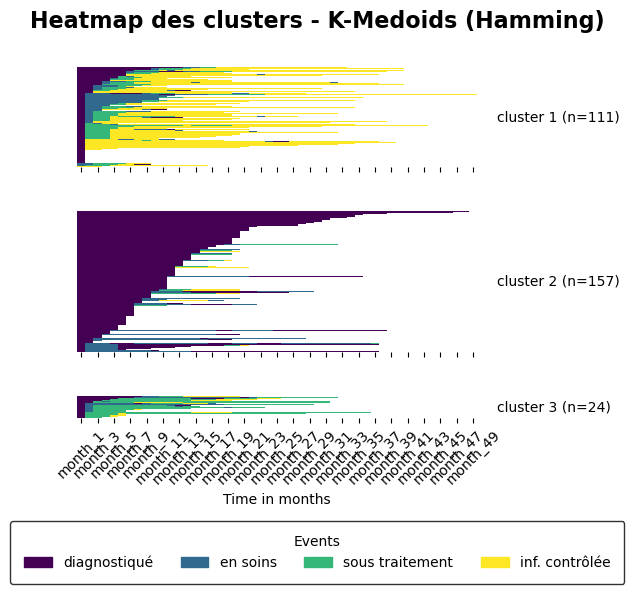

In [17]:
clusters_ham = tca.assign_clusters(linkage_matrix_ham, num_clusters=3)

methodes_clustering_ham = {
    "CAH (Hamming)": clusters_ham,
    "K-Medoids (Hamming)": kmedoids_labels_ham,
}

for titre, labels in methodes_clustering_ham.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

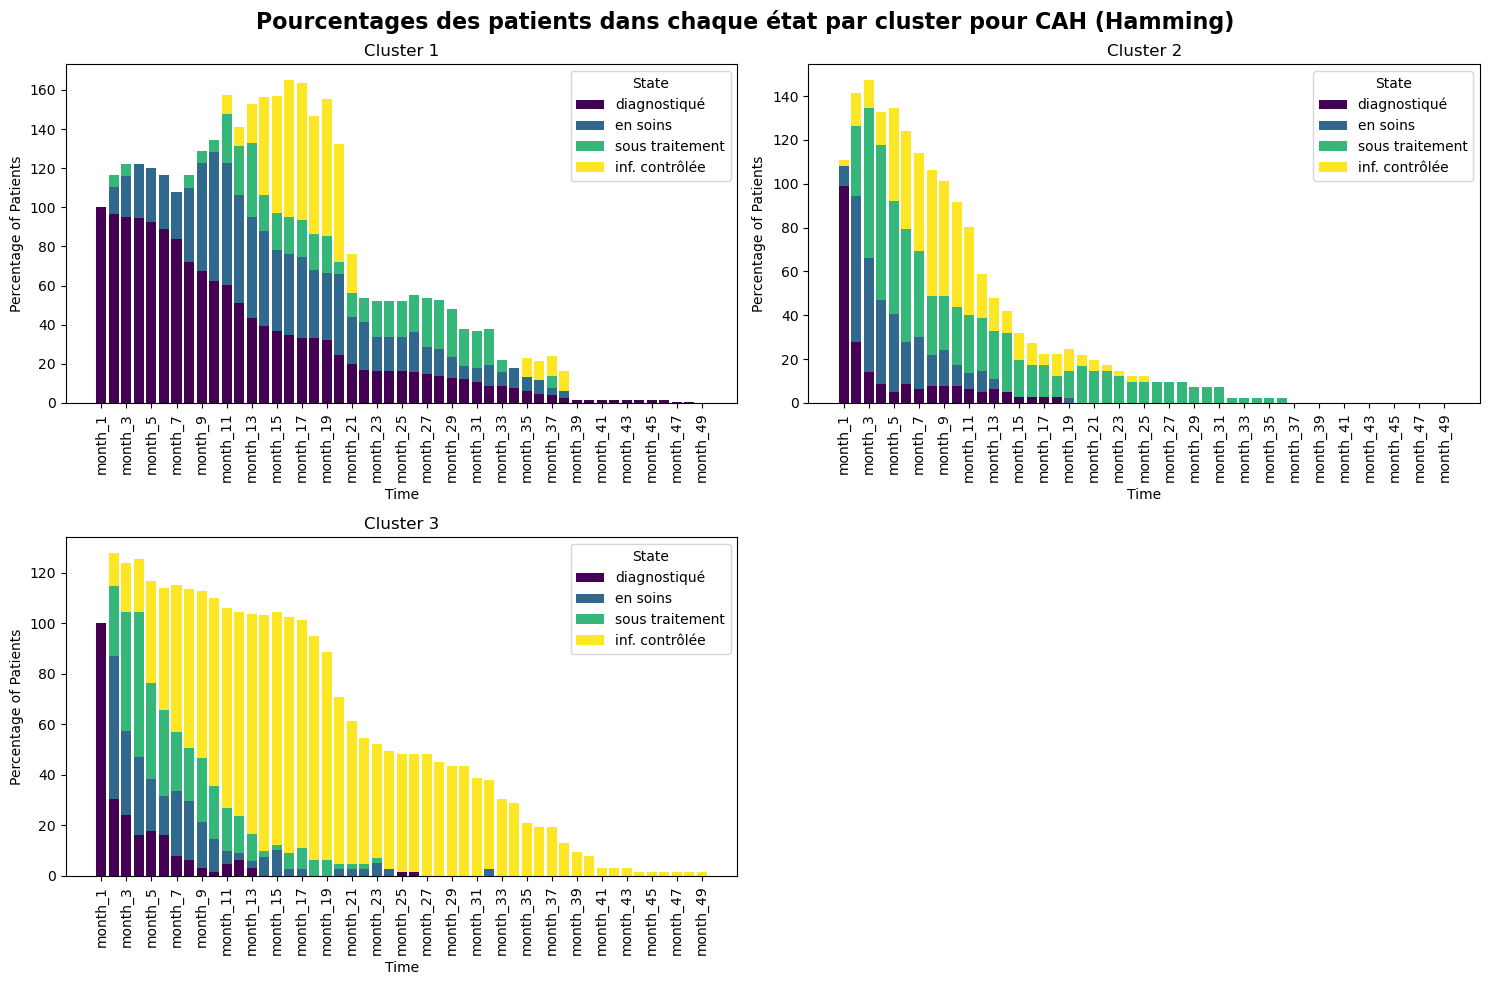

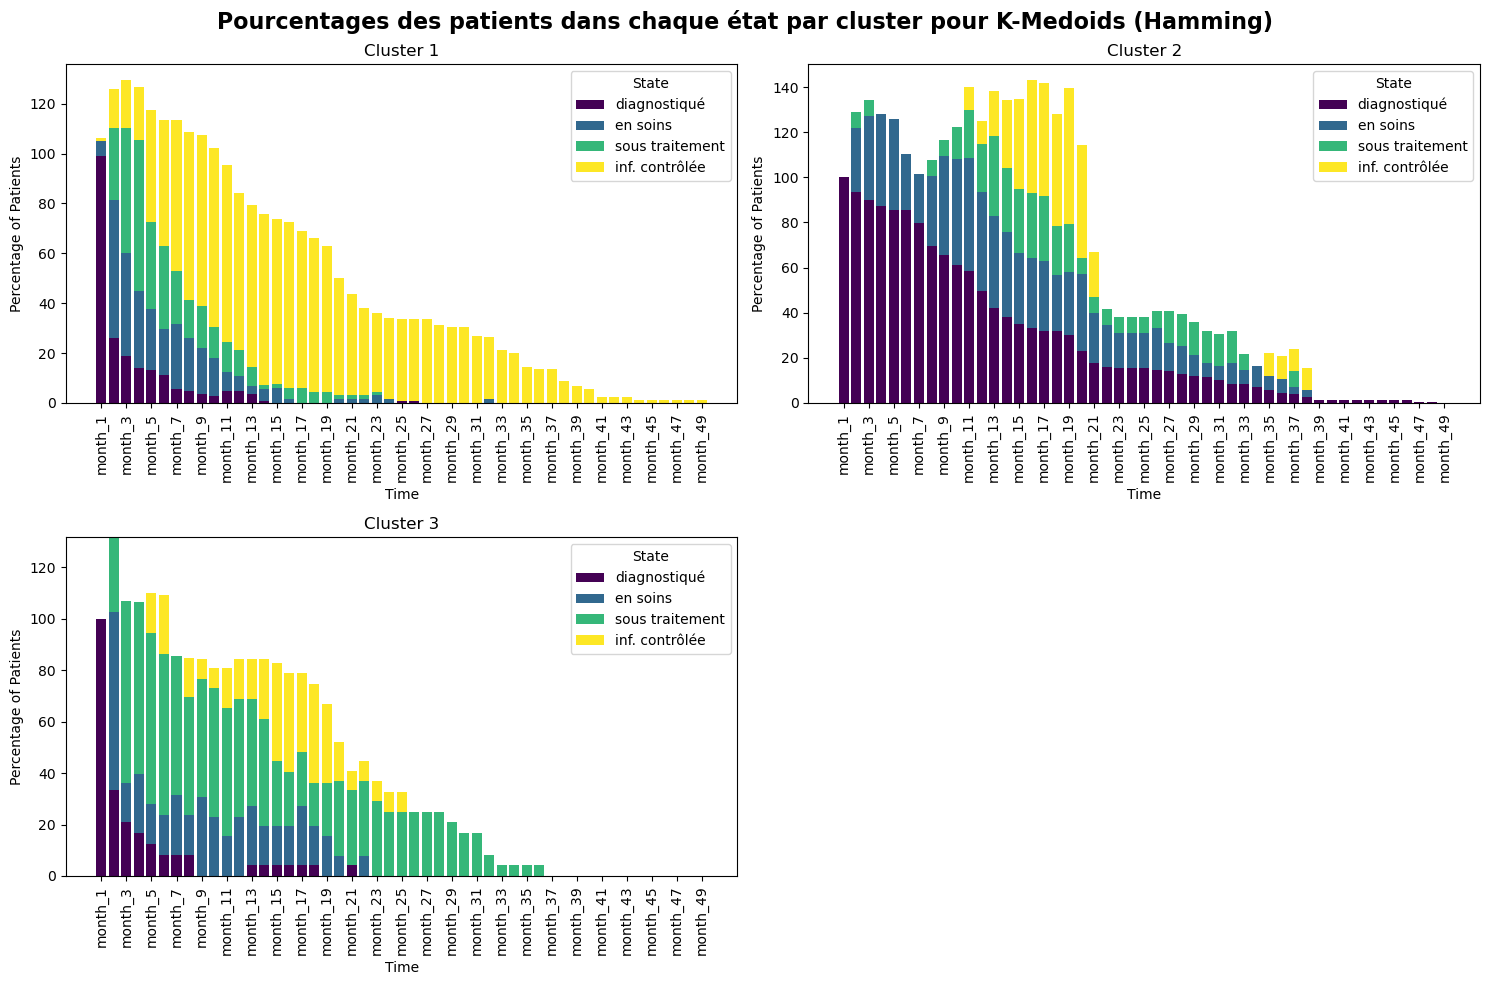

In [18]:
tca.bar_treatment_percentage(clusters=clusters_ham, title="Pourcentages des patients dans chaque état par cluster pour CAH (Hamming)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_ham, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Hamming)")

## 4.2. Distance de Levenshtein

### 4.2.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


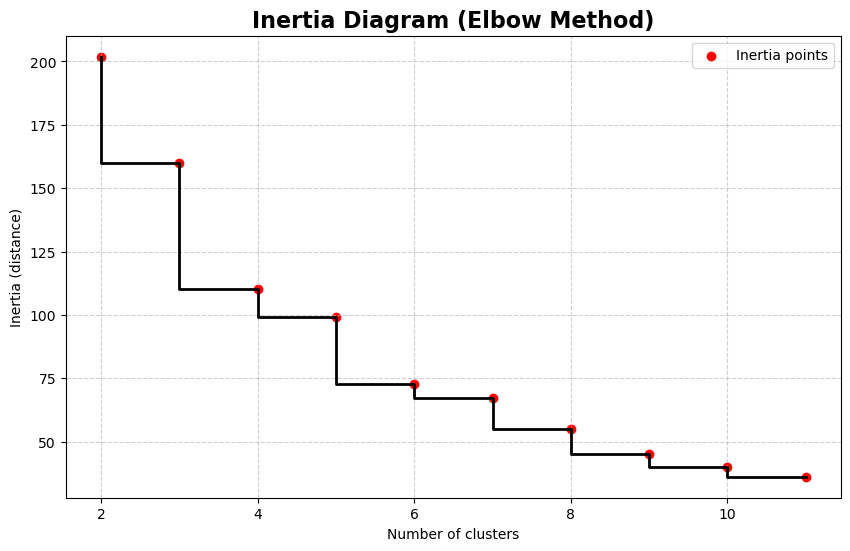

In [19]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_lev = tca.hierarchical_clustering(distance_matrix_lev)
#tca.plot_dendrogram(linkage_matrix_lev)
#tca.plot_clustermap(tca.data,linkage_matrix_lev)
tca.plot_inertia(linkage_matrix_lev)

### 4.2.2. K-medoids

In [20]:
kmedoids_labels_lev, medoid_indices_lev, inertia_med_lev = tca.kmedoids_clustering(distance_matrix_lev, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Levenshtein) :", np.unique(kmedoids_labels_lev))
print("medoid_indices (Levenshtein) :", medoid_indices_lev)
print("inertia (Levenshtein) :", inertia_med_lev)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Levenshtein) : [1 2 3]
medoid_indices (Levenshtein) : [ 29  18 102]
inertia (Levenshtein) : 2256.0


### 4.2.3. Heatmaps

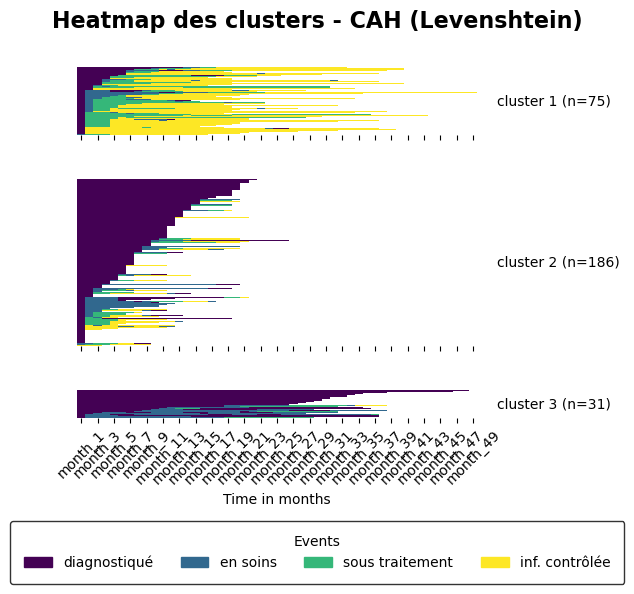

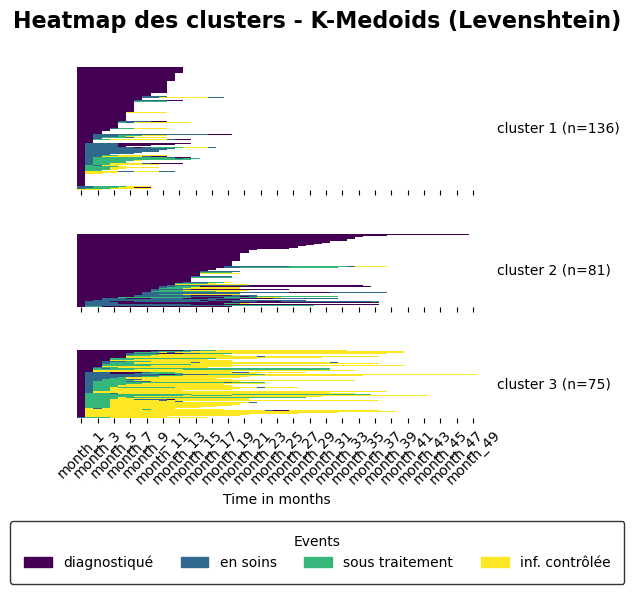

In [21]:
clusters_lev = tca.assign_clusters(linkage_matrix_lev, num_clusters=3)

methodes_clustering_lev = {
    "CAH (Levenshtein)": clusters_lev,
    "K-Medoids (Levenshtein)": kmedoids_labels_lev,
}

for titre, labels in methodes_clustering_lev.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

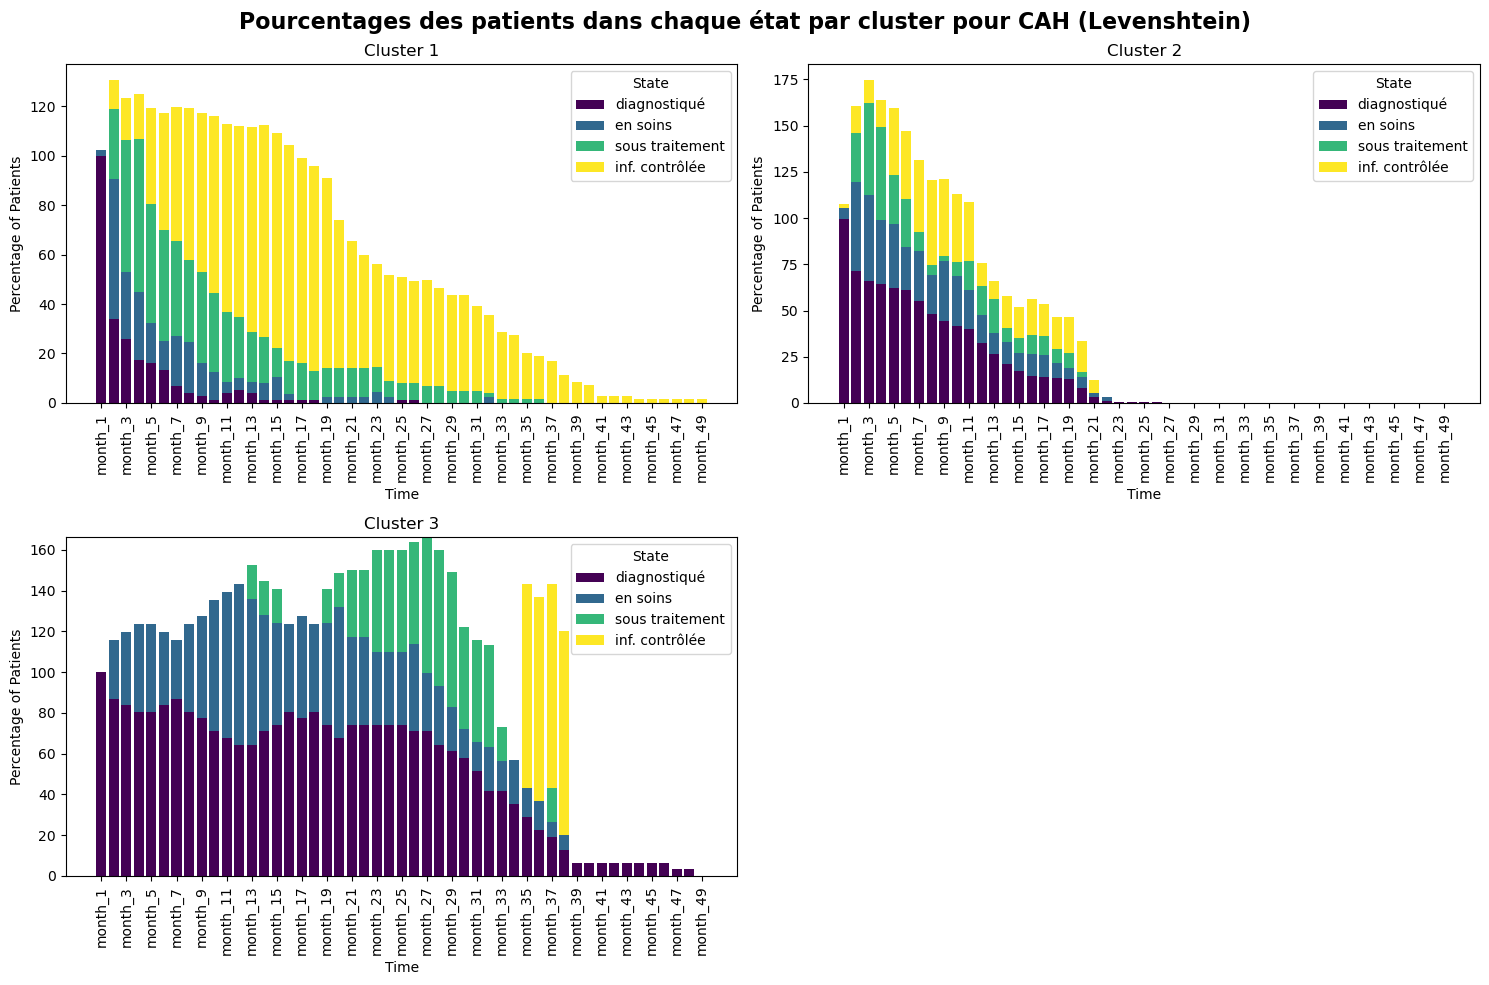

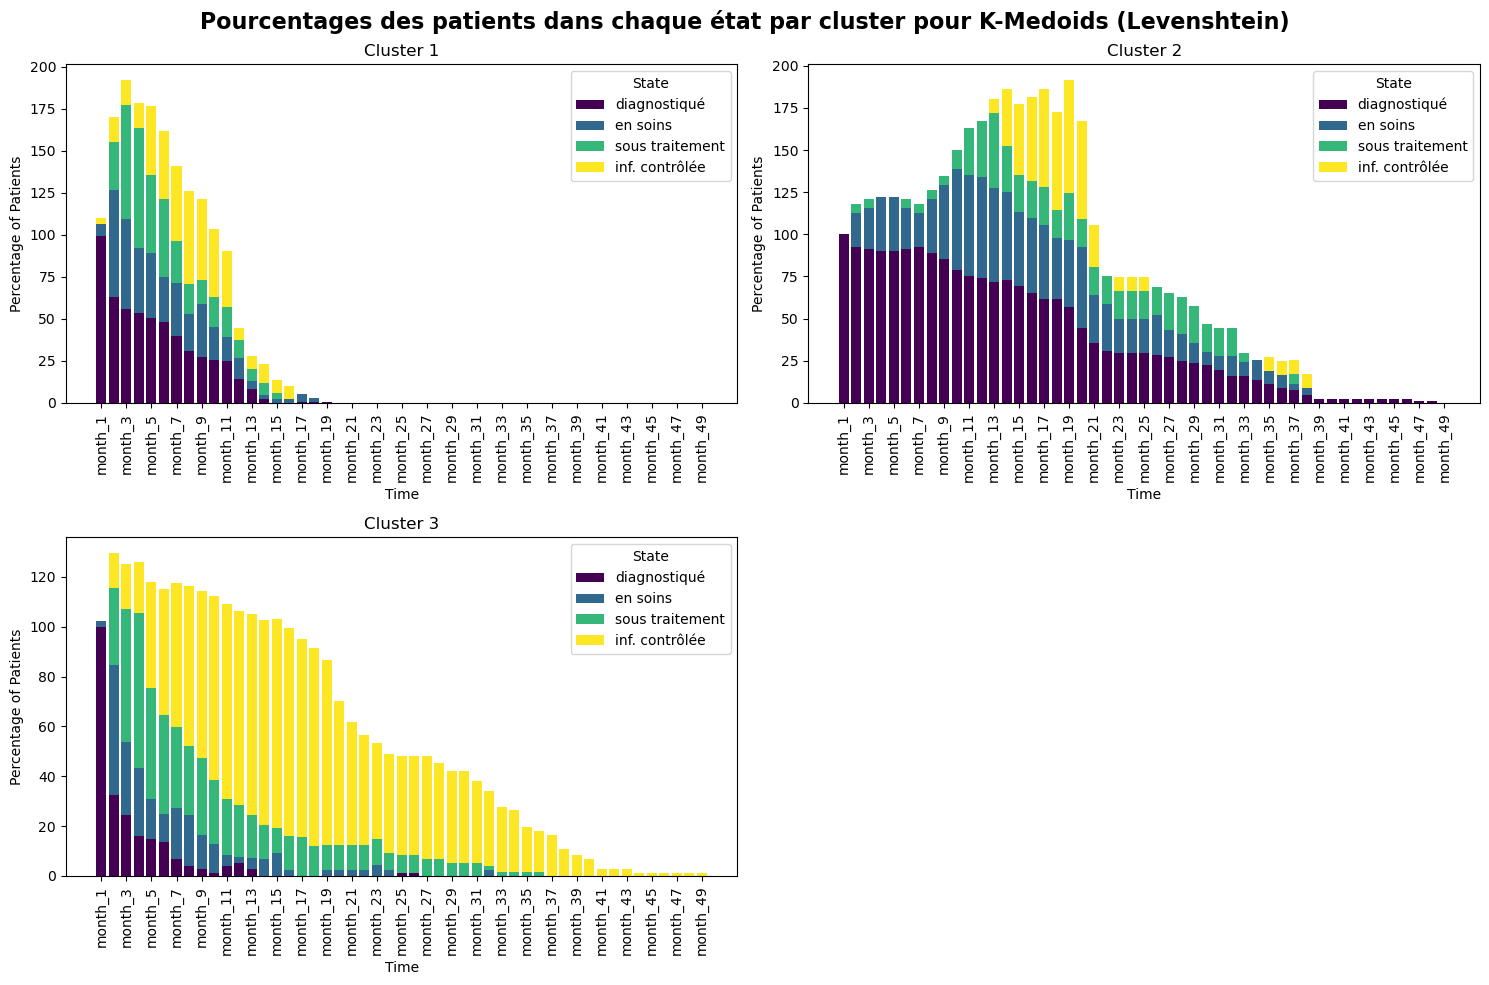

In [22]:
tca.bar_treatment_percentage(clusters=clusters_lev, title="Pourcentages des patients dans chaque état par cluster pour CAH (Levenshtein)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_lev, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Levenshtein)")

## 4.3. Distance Optimal Matching

#### 4.3.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


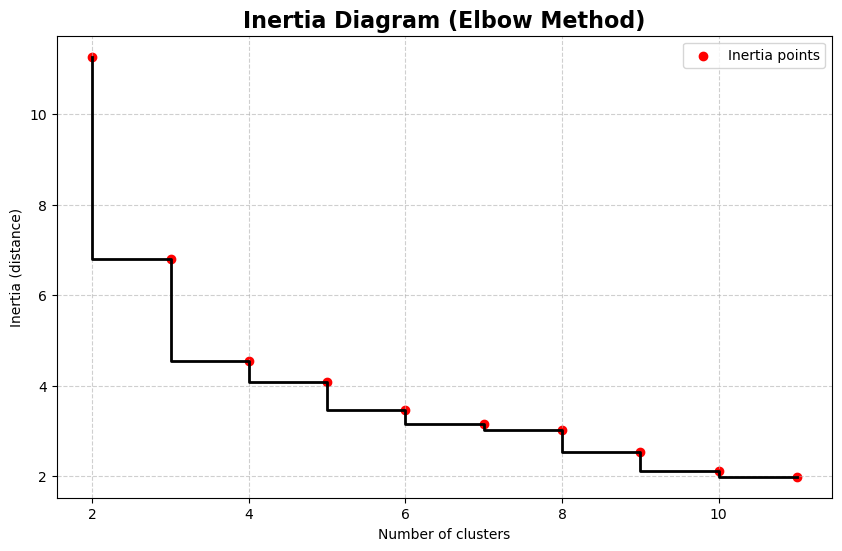

In [23]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_OM = tca.hierarchical_clustering(distance_matrix_OM)
#tca.plot_dendrogram(linkage_matrix_OM)
#tca.plot_clustermap(tca.data,linkage_matrix_OM)
tca.plot_inertia(linkage_matrix_OM)

3 clusters ici aussi

### 4.3.2. K-medoids

In [24]:
kmedoids_labels_OM, medoid_indices_OM, inertia_med_OM = tca.kmedoids_clustering(distance_matrix_OM, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Optimal Matching) :", np.unique(kmedoids_labels_OM))
print("medoid_indices (Optimal Matching) :", medoid_indices_OM)
print("inertia (Optimal Matching) :", inertia_med_OM)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Optimal Matching) : [1 2 3]
medoid_indices (Optimal Matching) : [ 96  72 287]
inertia (Optimal Matching) : 135.80015654556607


### 4.3.3. Comparaison

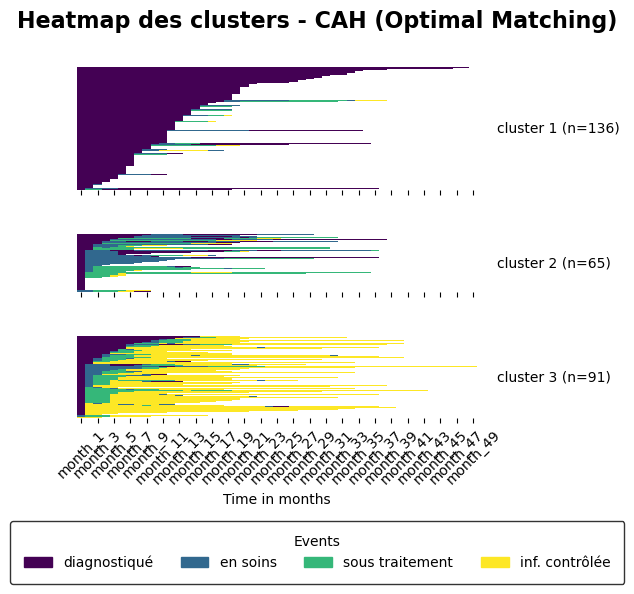

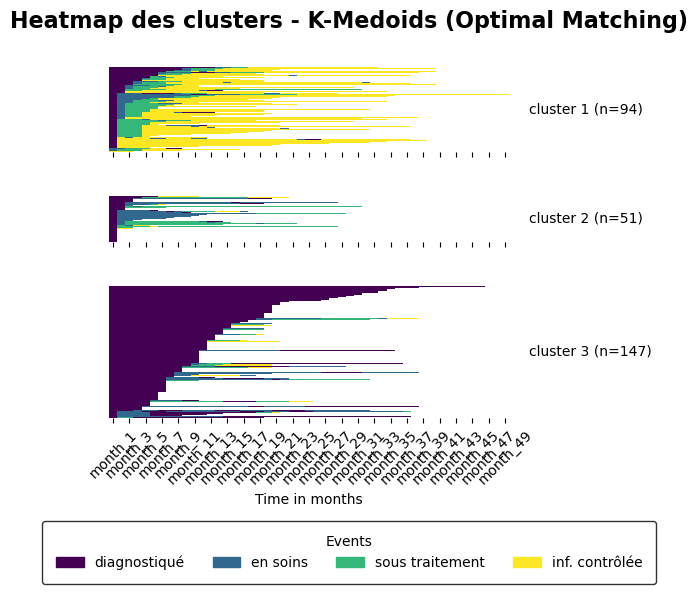

In [25]:
clusters_OM = tca.assign_clusters(linkage_matrix_OM, num_clusters=3)

methodes_clustering_OM = {
    "CAH (Optimal Matching)": clusters_OM,
    "K-Medoids (Optimal Matching)": kmedoids_labels_OM,
}

for titre, labels in methodes_clustering_OM.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

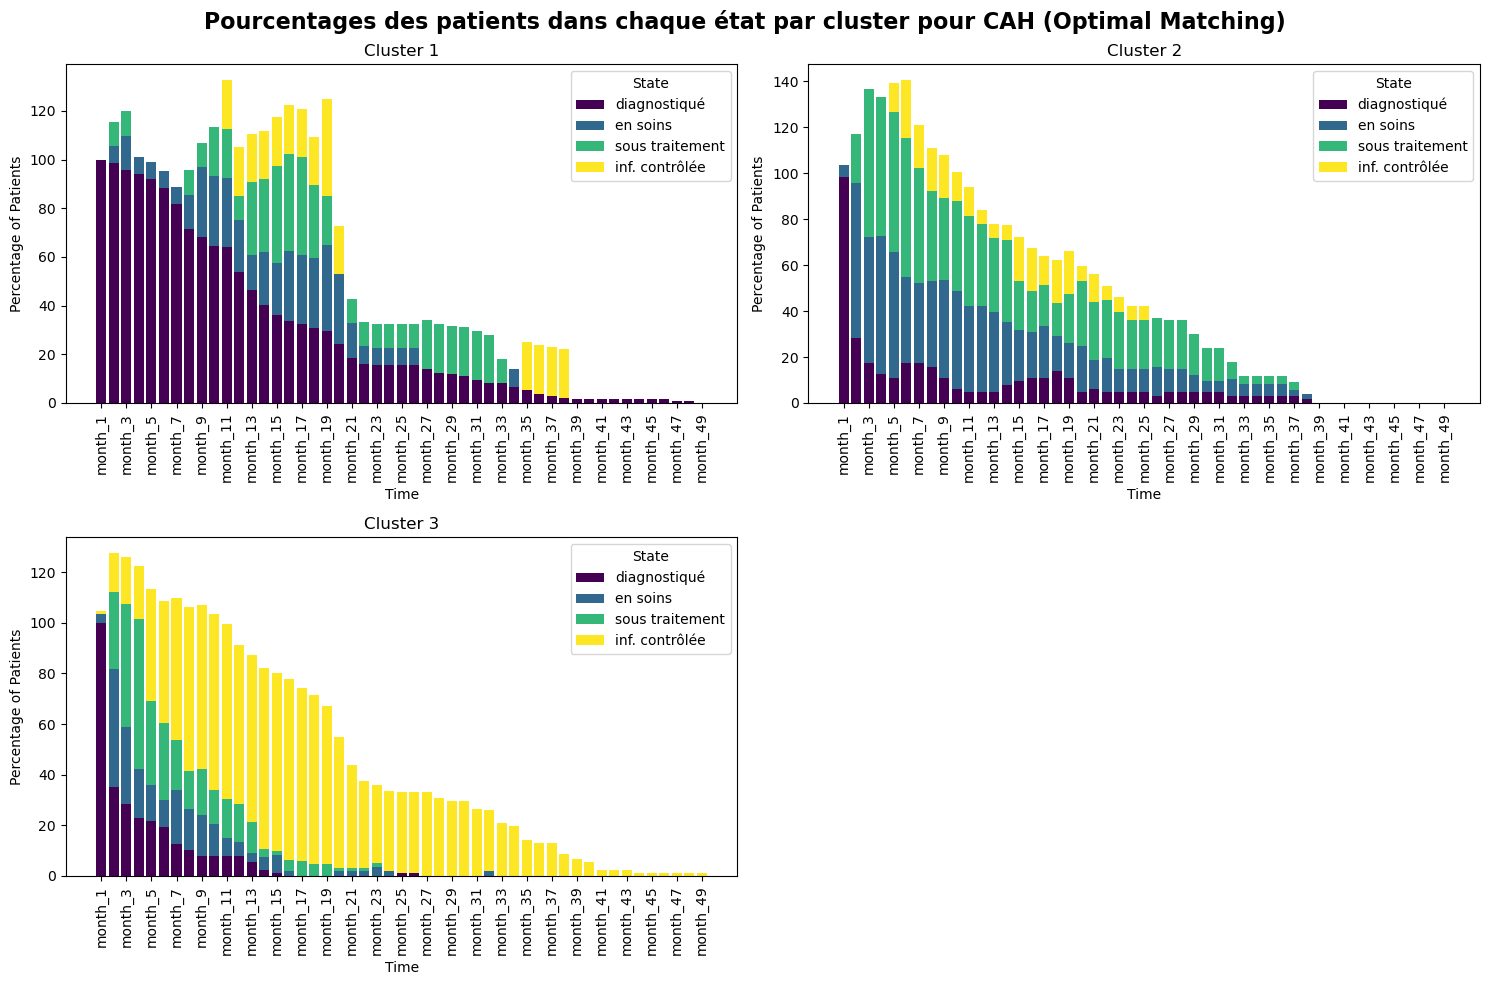

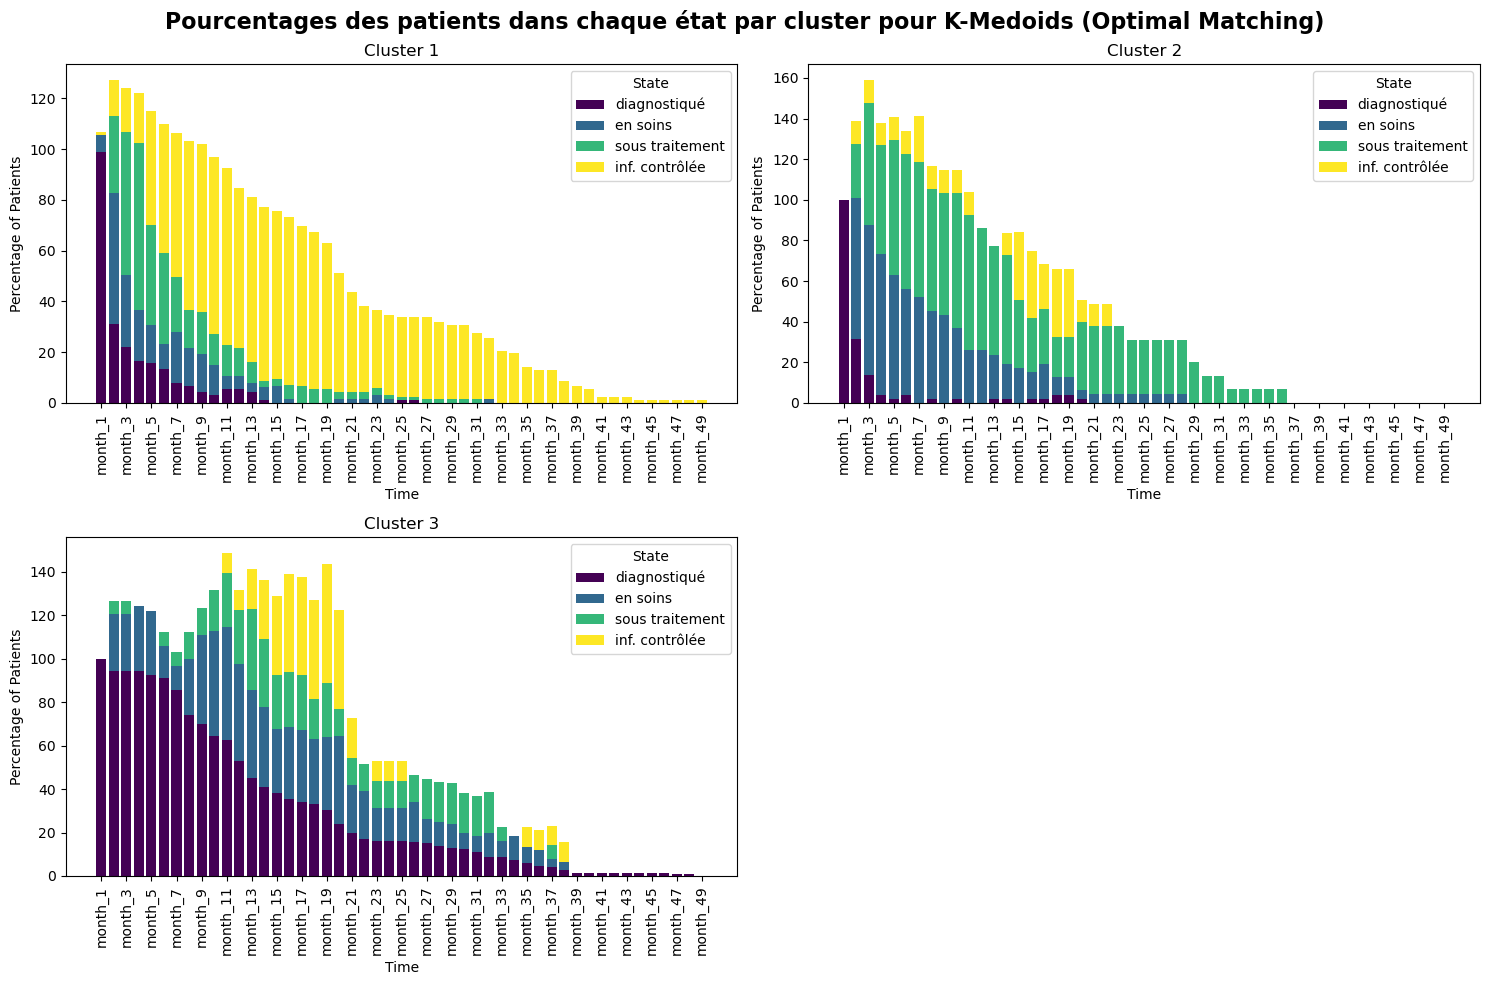

In [26]:
tca.bar_treatment_percentage(clusters=clusters_OM, title="Pourcentages des patients dans chaque état par cluster pour CAH (Optimal Matching)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_OM, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Optimal Matching)")

## 4.4. Distance de DTW

### 4.4.1. CAH 

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


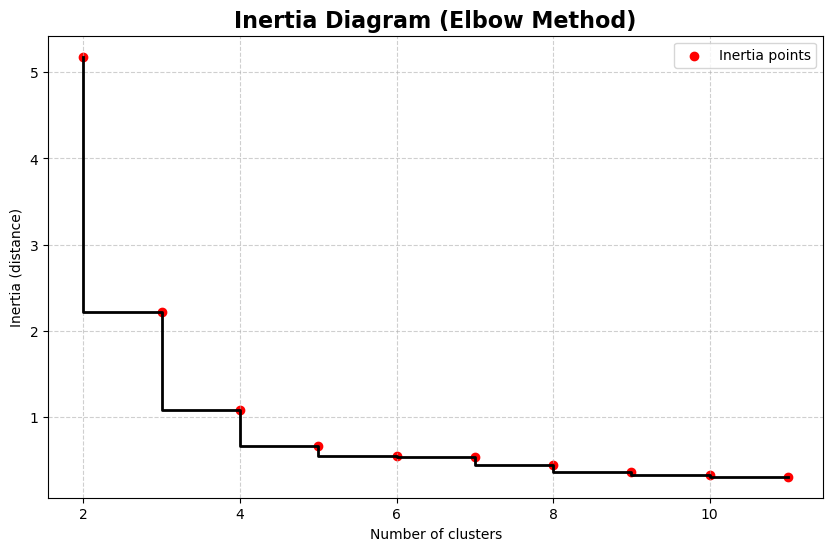

In [27]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_dtw = tca.hierarchical_clustering(distance_matrix_dtw)
#tca.plot_dendrogram(linkage_matrix_dtw)
#tca.plot_clustermap(tca.data,linkage_matrix_dtw)
tca.plot_inertia(linkage_matrix_dtw)

### 4.4.2. K-medoids

In [28]:
kmedoids_labels_dtw, medoid_indices_dtw, inertia_med_dtw = tca.kmedoids_clustering(distance_matrix_dtw, num_clusters=3,method='fasterpam')
print("kmedoids_labels (DTW) :", np.unique(kmedoids_labels_dtw))
print("medoid_indices (DTW) :", medoid_indices_dtw)
print("inertia (DTW) :", inertia_med_dtw)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (DTW) : [1 2 3]
medoid_indices (DTW) : [226  37 163]
inertia (DTW) : 6.896215030751313


### 4.4.3. Heatmaps

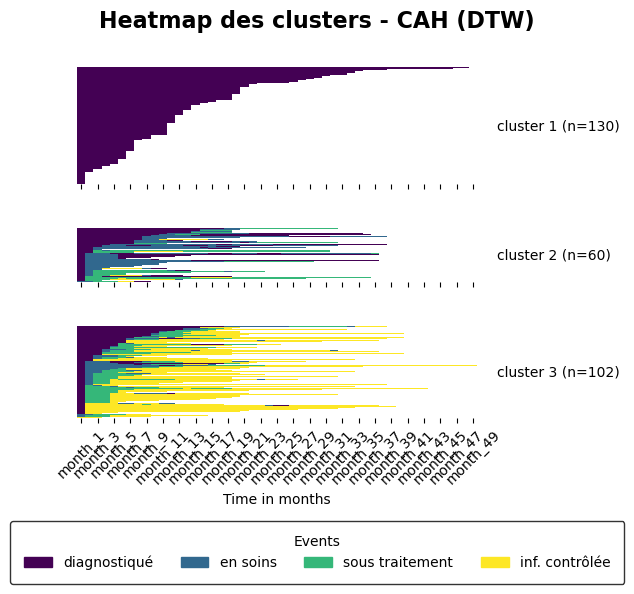

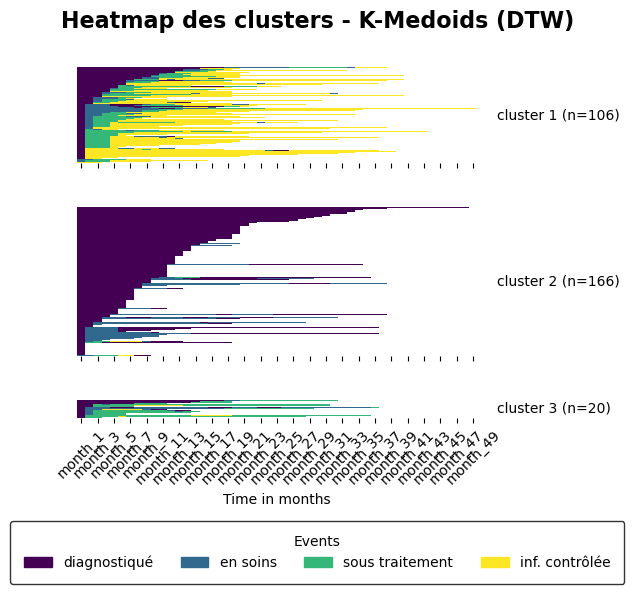

In [29]:
clusters_dtw = tca.assign_clusters(linkage_matrix_dtw, num_clusters=3)

methodes_clustering_dtw = {
    "CAH (DTW)": clusters_dtw,
    "K-Medoids (DTW)": kmedoids_labels_dtw,
}

for titre, labels in methodes_clustering_dtw.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

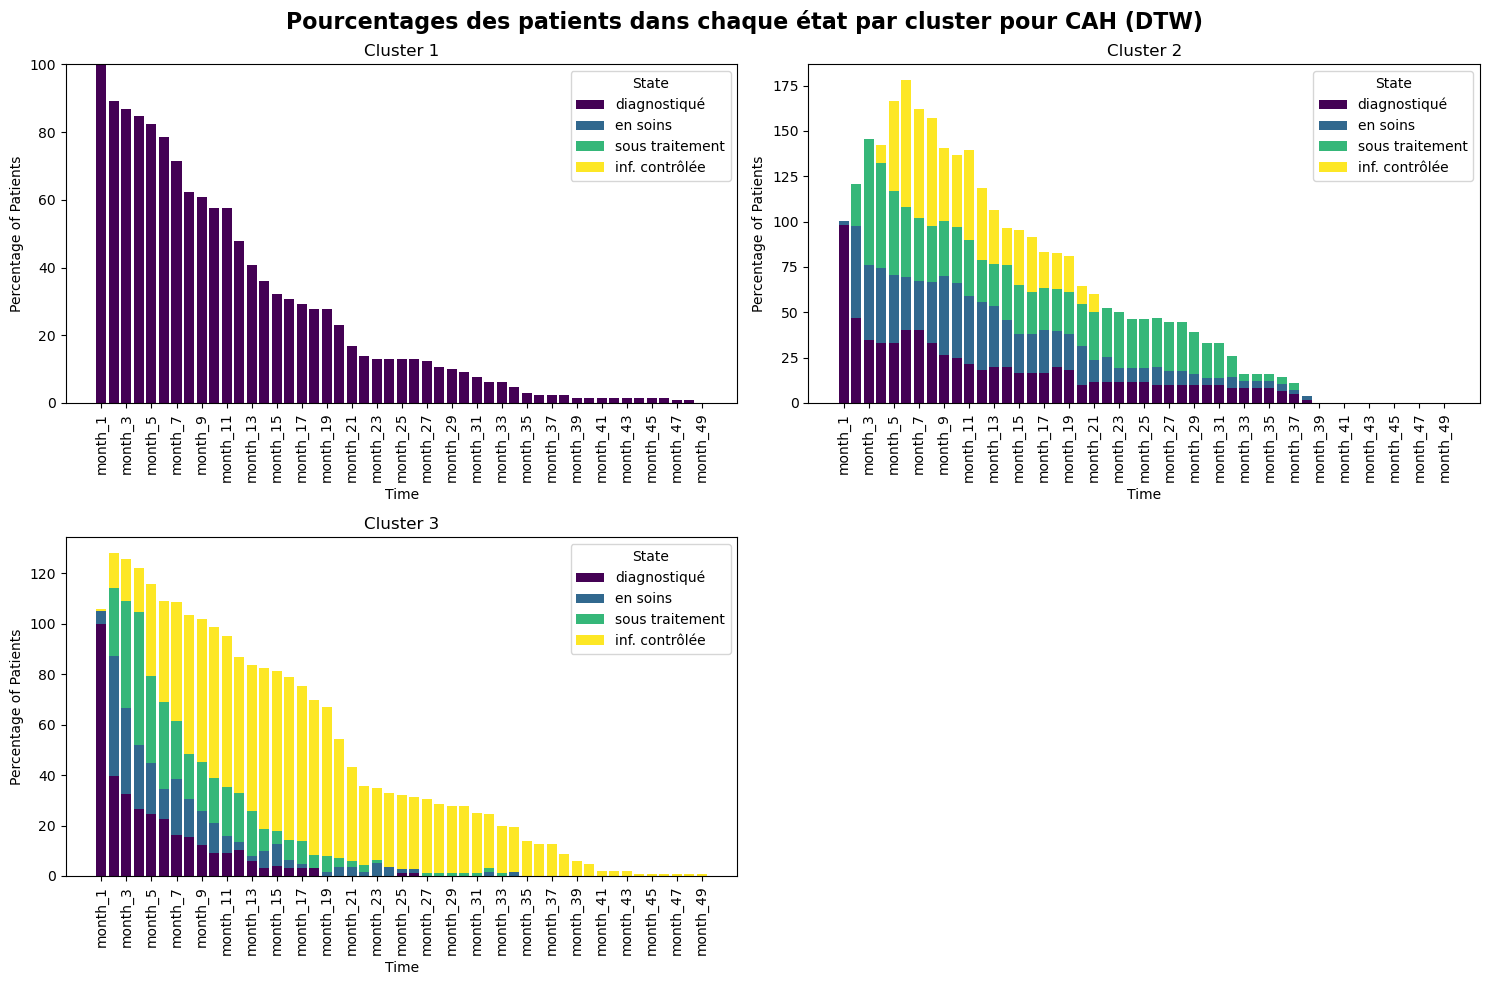

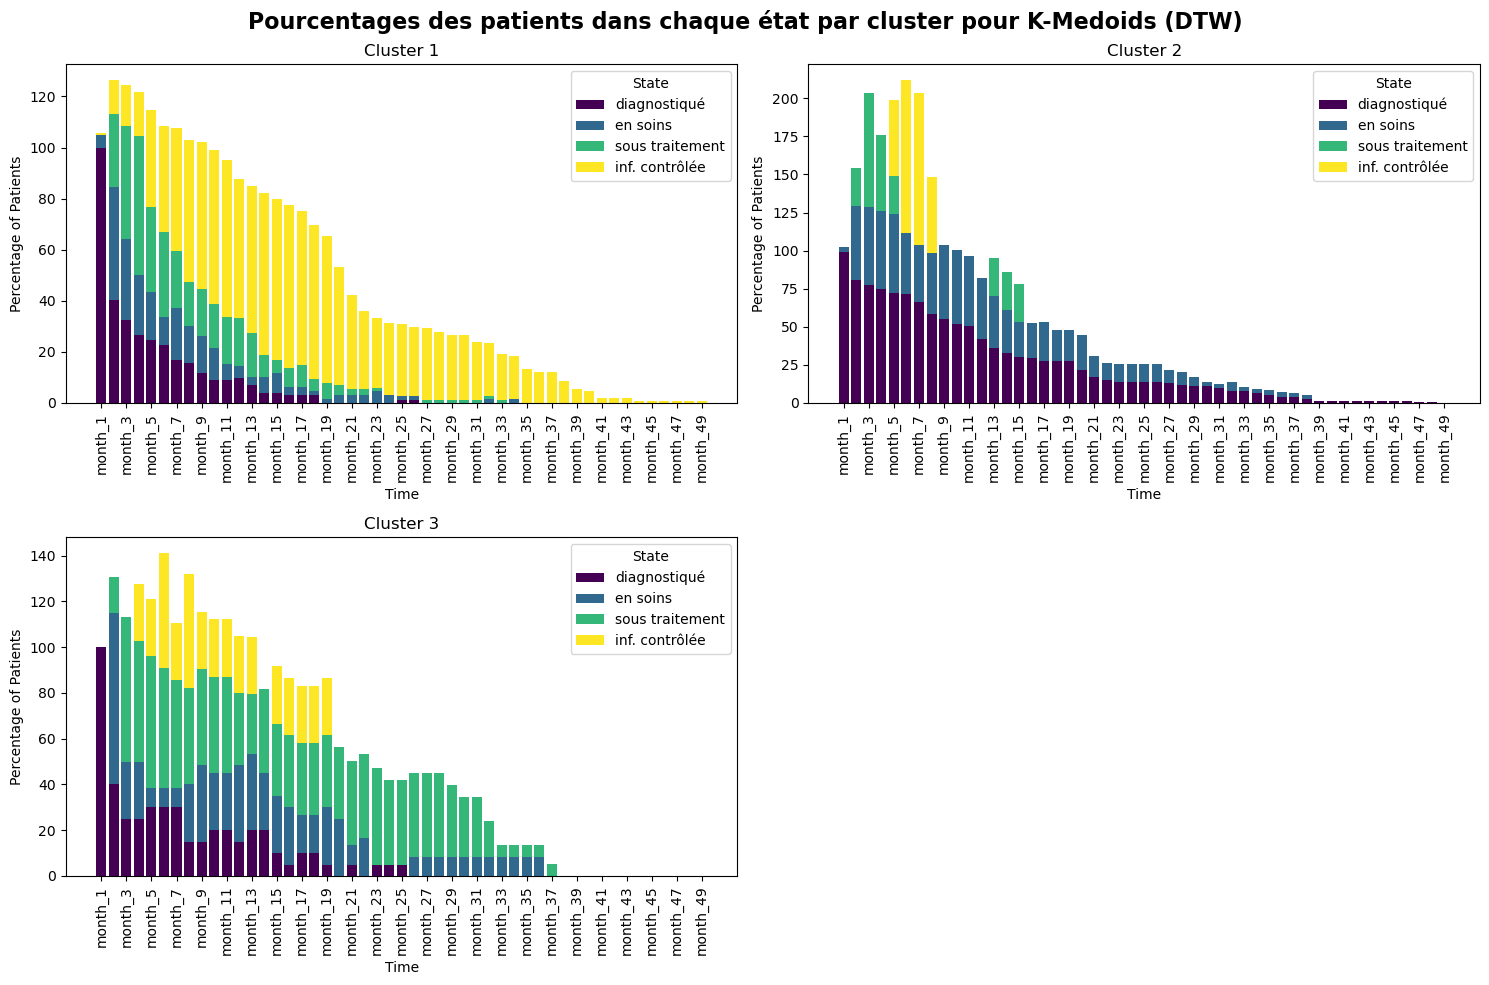

In [30]:
tca.bar_treatment_percentage(clusters=clusters_dtw, title="Pourcentages des patients dans chaque état par cluster pour CAH (DTW)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_dtw, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (DTW)")

## 4.5. Distance GAK

### 4.5.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


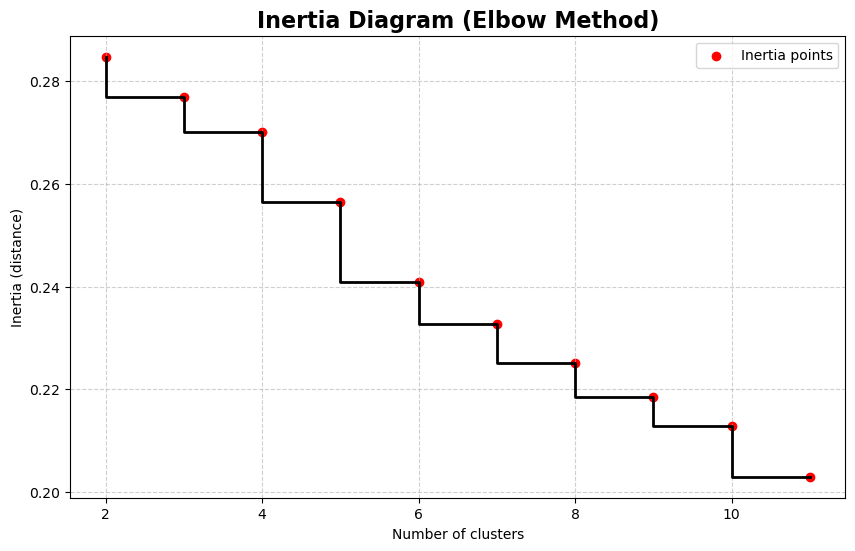

In [31]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_gak = tca.hierarchical_clustering(distance_matrix_gak)
#tca.plot_dendrogram(linkage_matrix_gak)
#tca.plot_clustermap(tca.data,linkage_matrix_gak)
tca.plot_inertia(linkage_matrix_gak)

### 4.5.2. K-medoids

In [32]:
kmedoids_labels_gak, medoid_indices_gak, inertia_med_gak = tca.kmedoids_clustering(distance_matrix_gak, num_clusters=3,method='fasterpam')
print("kmedoids_labels (GAK) :", np.unique(kmedoids_labels_gak))
print("medoid_indices (GAK) :", medoid_indices_gak)
print("inertia (GAK) :", inertia_med_gak)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (GAK) : [1 2 3]
medoid_indices (GAK) : [281  37  16]
inertia (GAK) : 1.6105304022545025e-21


### 4.5.3. Comparaison

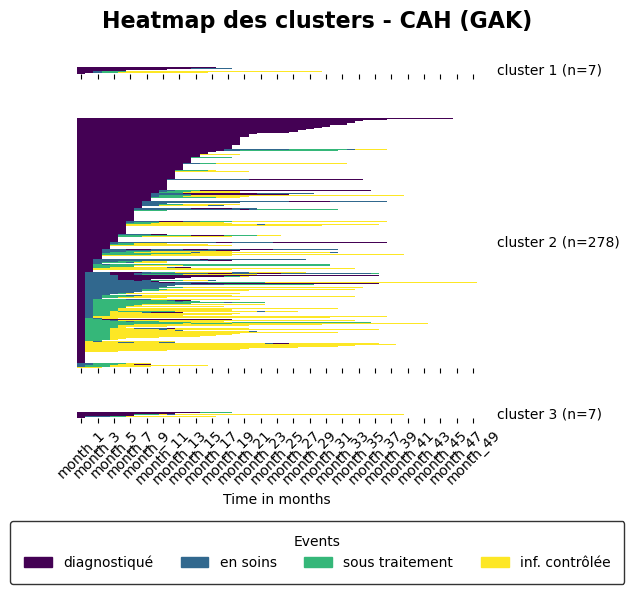

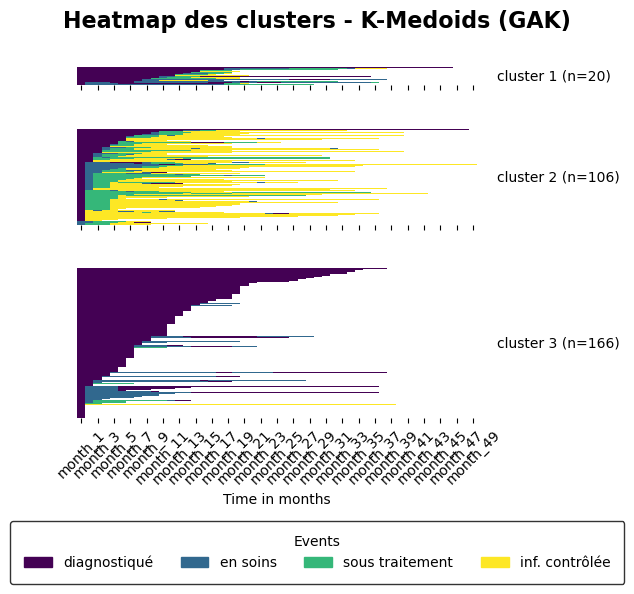

In [33]:
clusters_gak = tca.assign_clusters(linkage_matrix_gak, num_clusters=3)

methodes_clustering_gak = {
    "CAH (GAK)": clusters_gak,
    "K-Medoids (GAK)": kmedoids_labels_gak,
}

for titre, labels in methodes_clustering_gak.items():    
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

Pour cette distance, avec CAH, on a le cluster 2 qui a presque tous les patients, et les clusters 1 et 3 qui n'en n'ont que très peu, il ne peut pas permettre de généraliser

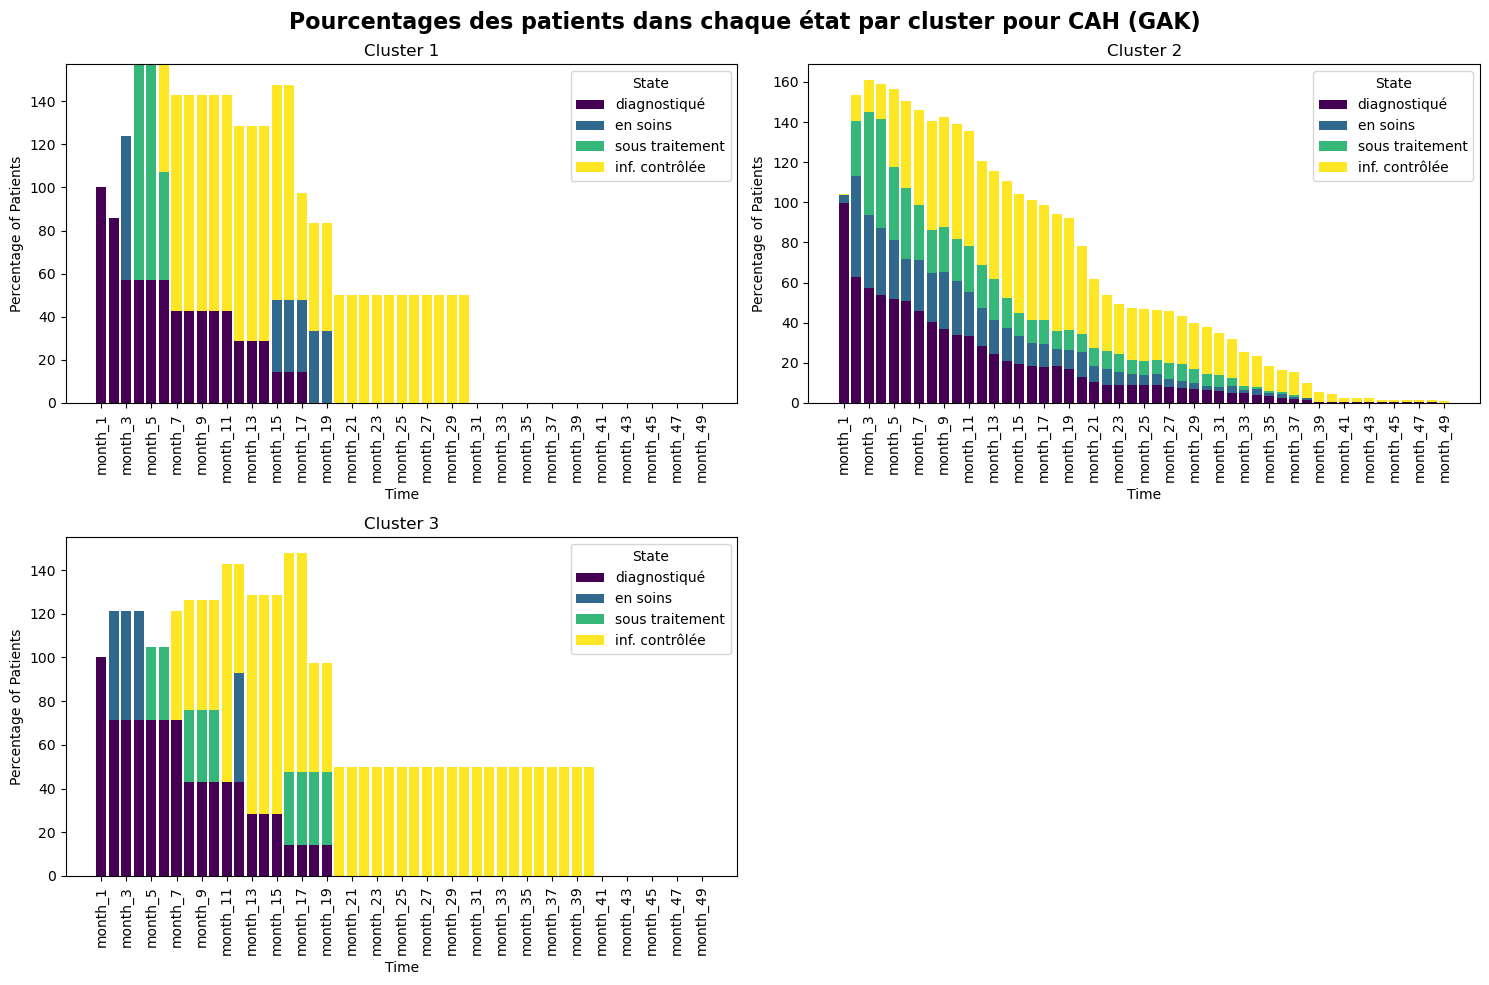

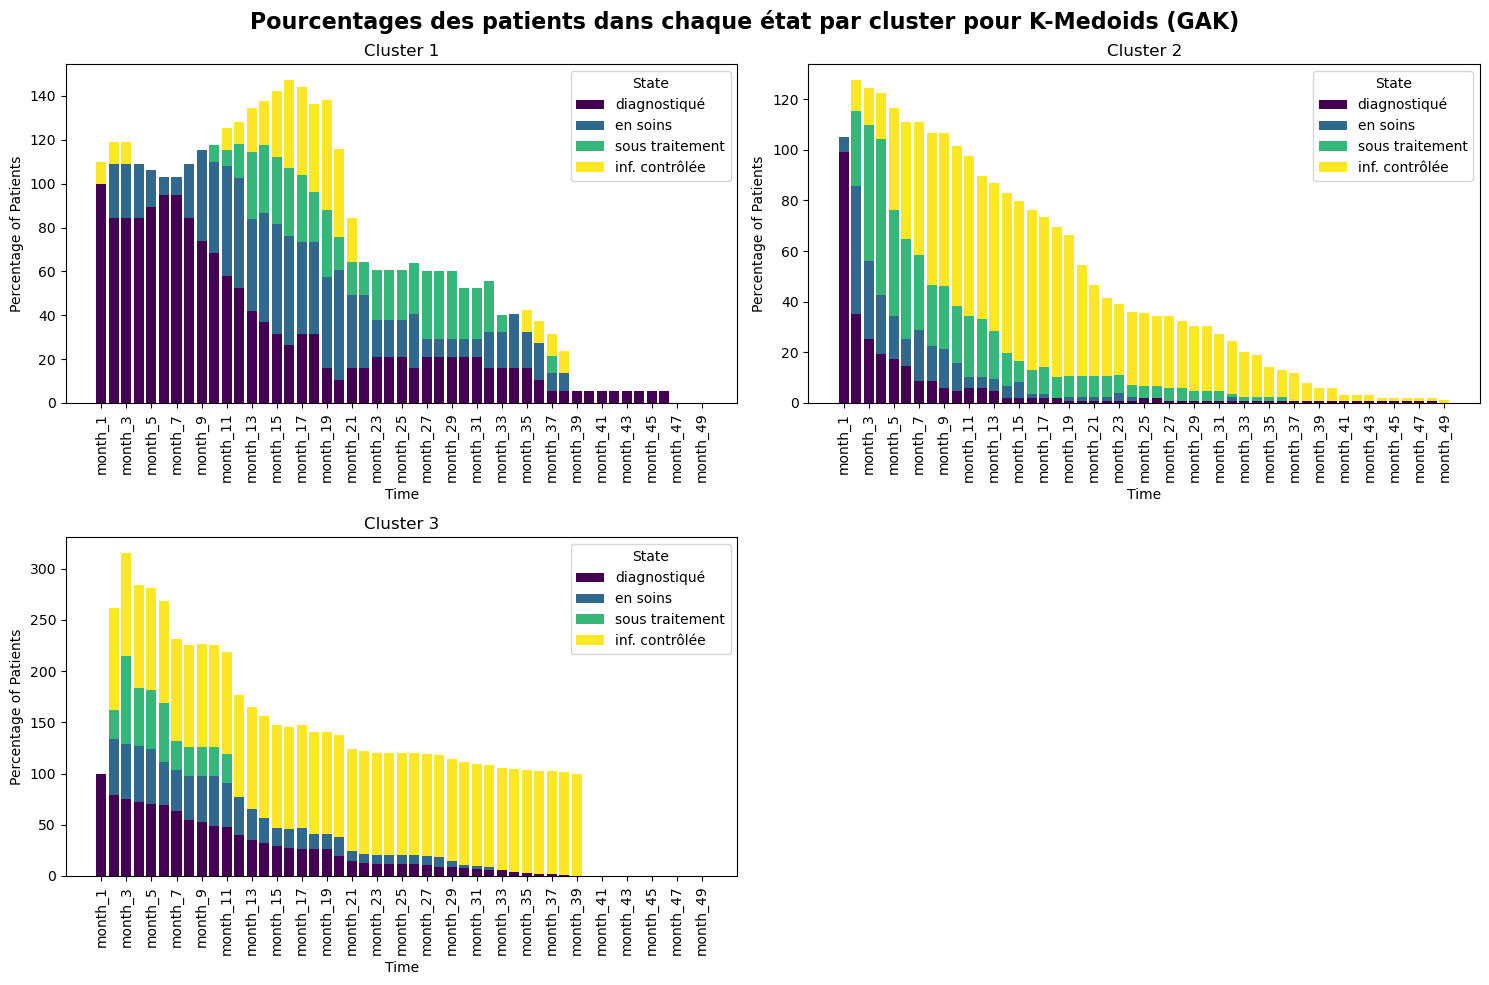

In [34]:
tca.bar_treatment_percentage(clusters=clusters_gak, title="Pourcentages des patients dans chaque état par cluster pour CAH (GAK)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_gak, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (GAK)")

On remarque que pour OM, pour CAH, on avait bien un cluster avec une grande majorité de patients qui sont seulement diagnostiqués, un 2ème avec les patients qui sont encore sous traitements ou en soins à la fin de l'étude, et un dernier avec une majorité de patients qui ont l'infection contrôlée à la fin.
Et pour K-medoids, on avait la même chose mais avec les clusters 1 et 3 inversés.

Il semble donc intéréssants de se centrer sur la métrique OM pour la suite de nos interprétations. 

# 5. Ajouts

On peut maintenant faire nos analyses pour une seule distance, ici on choisit Optimal Matching (elle tourne assez rapidement au final)

## 5.1. Entropie transversale (Traminer)
L'entropie montre à quel point les patients sont dispersés ou non à un instant $t$. L'entropie mesure le désordre :
- Entropie = 0 : Tous les patients sont dans le même état (ex: tout le monde est au stade "Diagnostic").
- Entropie = 1 (maximum) : Les patients sont répartis équitablement entre tous les états possibles. C'est la diversité maximale.

Pic d'entropie au début : Signifie que les patients commencent leur parcours de manières très différentes.

Baisse de l'entropie à la fin : Signifie que le parcours de soins renvoie les patients vers un état commun (souvent la guérison ou la fin de suivi).

Un cluster avec une entropie toujours basse est un cluster "robuste" (prévisible). Un cluster avec une entropie haute est un groupe instable.

In [35]:
def plot_transversal_entropy(tca, clusters=None, title="Évolution de l'Entropie Transversale"):
        """
        Calcule et affiche l'entropie transversale (seqHtplot de TraMineR).
        Si 'clusters' est fourni, affiche une courbe par cluster.

        Paramètres:
        -----------
        tca : TCA object
            L'objet TCA contenant les données de séquences.
        clusters : array-like, optionnel
            Les labels de cluster pour chaque patient. Si None, affiche la moyenne pour l'ensemble des données.
        """        
        df_seqs = tca.data.drop(columns=[tca.index_col])
        time_points = df_seqs.columns
        n_states = len(tca.alphabet)

        def calculate_entropy(df):
            entropies = []
            for col in df.columns:
                # Calcul des proportions p_i pour chaque état
                probs = df[col].value_counts(normalize=True)
                # Formule de Shannon : -sum(p_i * log(p_i))
                # On normalise par log(n_states) pour avoir un score entre 0 et 1
                h = -np.sum(probs * np.log(probs)) / np.log(n_states) if n_states > 1 else 0
                entropies.append(h)
            return entropies

        plt.figure(figsize=(12, 6))

        if clusters is None:
            # Entropie globale
            overall_h = calculate_entropy(df_seqs)
            plt.plot(time_points, overall_h, label="Cohorte Totale", color='black', linewidth=3)
        else:
            # Une courbe par cluster
            unique_clusters = np.unique(clusters)
            for cluster in unique_clusters:
                cluster_data = df_seqs[clusters == cluster]
                cluster_h = calculate_entropy(cluster_data)
                plt.plot(time_points, cluster_h, label=f"Cluster {cluster}")

        plt.title(title, fontsize=15, fontweight='bold')
        plt.xlabel("Temps (Mois)")
        plt.ylabel("Indice d'Entropie (Normalisé)")
        plt.ylim(0, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title="Groupes", bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


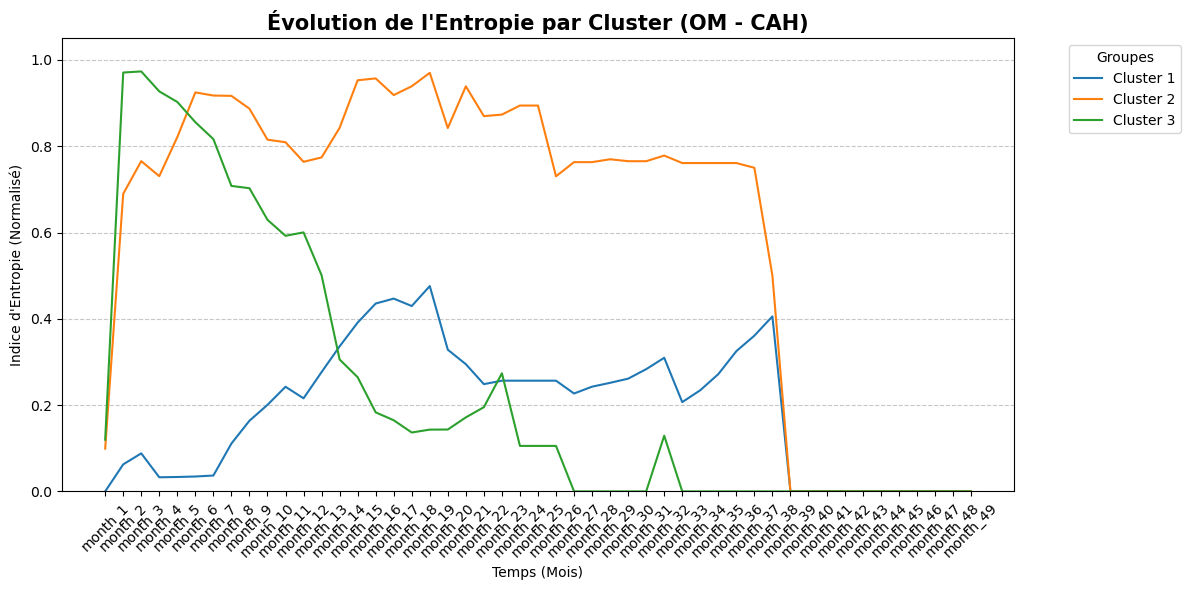

In [36]:
plot_transversal_entropy(tca, clusters=clusters_OM, title="Évolution de l'Entropie par Cluster (OM - CAH)")

Le cluster 1 a une entropie faible au début, les patients sont tous dans le même état D, puis l'entropie augmente légèrement, on a certains patients qui passent aux états de soins et de traitements.

Le cluster 3 arrive assez rapidement à une entropie nulle, tous les patients finissent par avoir le même état (infection contrôlée)

Et le cluster 2 a une entropie qui tombe à 0 car on arrive à la fin de l'étude et donc tous les patients sont à l'état nan, mais on a une entropie assez élevée tout le long, on alterne entre plusieurs états.

Cette fonction semble donc plus intéresantes pour des variables comme mvad_data, on saura que lorsque l'entropie s'approche de 0, ce n'est pas à caus d'un manque d'information mais parce que les patients finissent par avoir le même état.

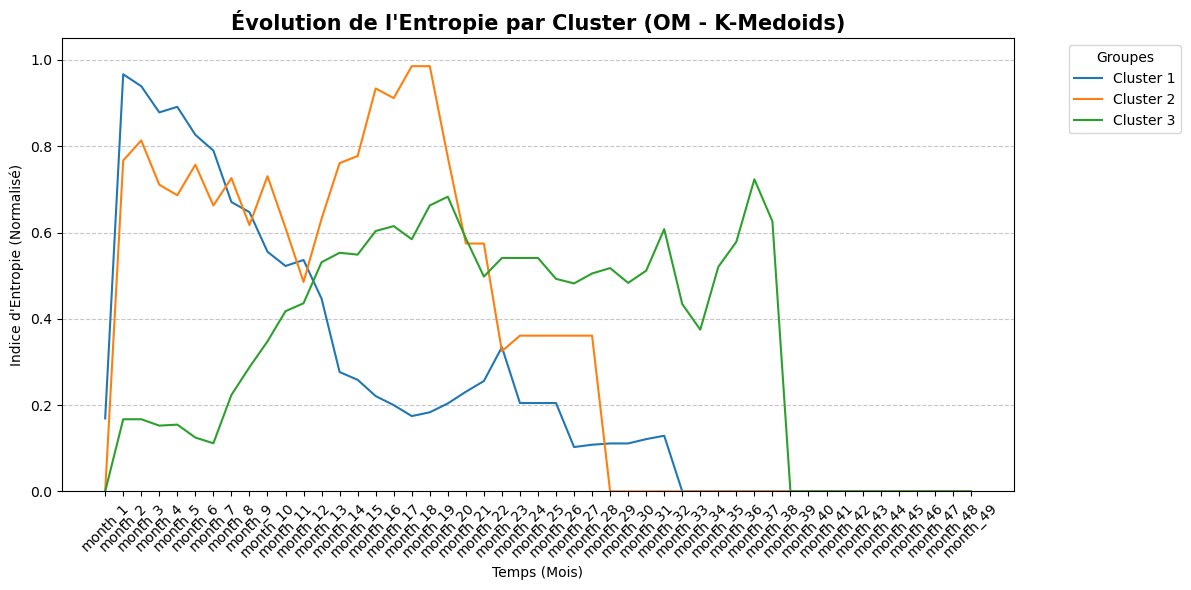

In [37]:
plot_transversal_entropy(tca, clusters=kmedoids_labels_OM, title="Évolution de l'Entropie par Cluster (OM - K-Medoids)")

Pour k-medoids, les clusters 1 et 2 ont assez rapidement une entropie nulle. Mais on remarque pour le cluster 1 l'entropie augmente au cours des mois.

## 5.2. Mean Time Plot (Traminer)

Durée Moyenne par État (Equivalent `seqmtplot`) : Ce graphique donne le temps total passé dans chaque phase du parcours de soins. Celui-ci montre combien de temps durent les états.

In [38]:
def plot_mean_time(tca, clusters=None, title="Temps Moyen passé dans chaque État"):
        """
        Calcule et affiche le temps moyen passé dans chaque état (seqmtplot).

        Paramètres:
        ----------- 
        tca : TCA object
            L'objet TCA contenant les données de séquences.
        clusters : array-like, optionnel
            Les labels de cluster pour chaque patient. Si None, affiche la moyenne pour l'ensemble des données.
        """
        df_seqs = tca.data.drop(columns=[tca.index_col])
        
        def get_means(df):
            # Compte les occurrences de chaque état pour chaque patient
            counts = df.apply(pd.Series.value_counts, dropna=False, axis=1).fillna(0)
            # S'assure que tous les états de l'alphabet sont présents
            for state in tca.alphabet:
                if state not in counts.columns:
                    counts[state] = 0
            # Calcule la moyenne et réordonne selon l'alphabet
            return counts[tca.alphabet].mean()

        plt.figure(figsize=(10, 6))
        
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(len(tca.alphabet))]

        if clusters is None:
            means = get_means(df_seqs)
            bars = plt.bar(tca.states, means, color=colors, edgecolor='black', alpha=0.8)
            plt.ylabel("Nombre moyen de mois")
        else:
            # Comparaison par cluster (Barres groupées)
            unique_clusters = np.unique(clusters)
            n_clusters = len(unique_clusters)
            width = 0.8 / n_clusters
            x = np.arange(len(tca.states))

            for i, cluster in enumerate(unique_clusters):
                cluster_means = get_means(df_seqs[clusters == cluster])
                plt.bar(x + i*width, cluster_means, width, label=f"Cluster {cluster}", alpha=0.8)
            
            plt.xticks(x + width*(n_clusters-1)/2, tca.states)
            plt.ylabel("Durée moyenne (Mois)")
            plt.legend(title="Groupes", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(title, fontsize=15, fontweight='bold', pad=15)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

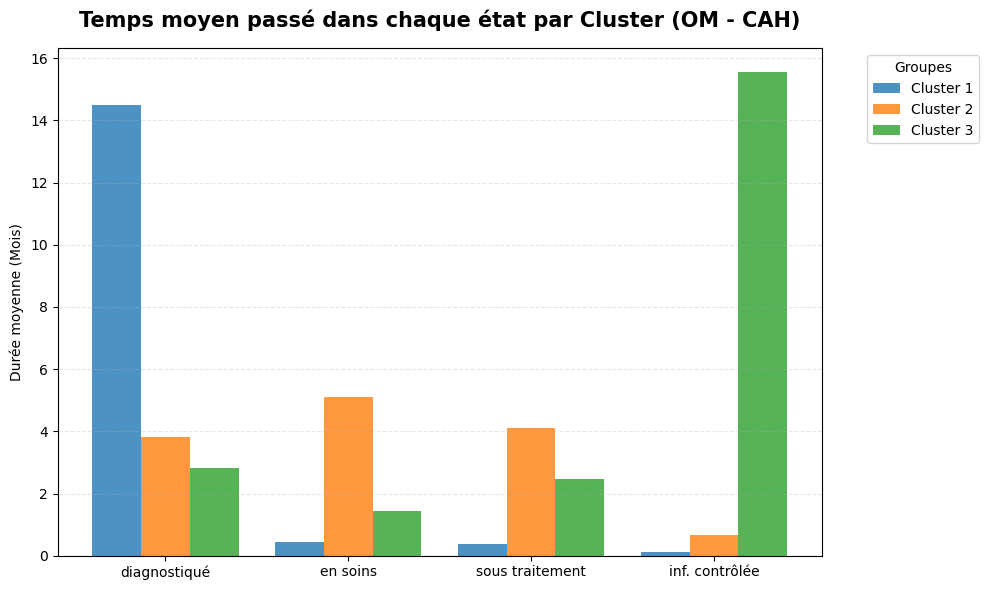

In [39]:
plot_mean_time(tca, clusters=clusters_OM, title="Temps moyen passé dans chaque état par Cluster (OM - CAH)")

On voit que le cluster 1 est majoritairement dans l'état diagnostiqué, tandis que pour le cluster 2, on passe par tous les états mais on est assez peu dans infection controlée.
Alors que le cluster 3 est majoritairement à l'état d'infection controlée.

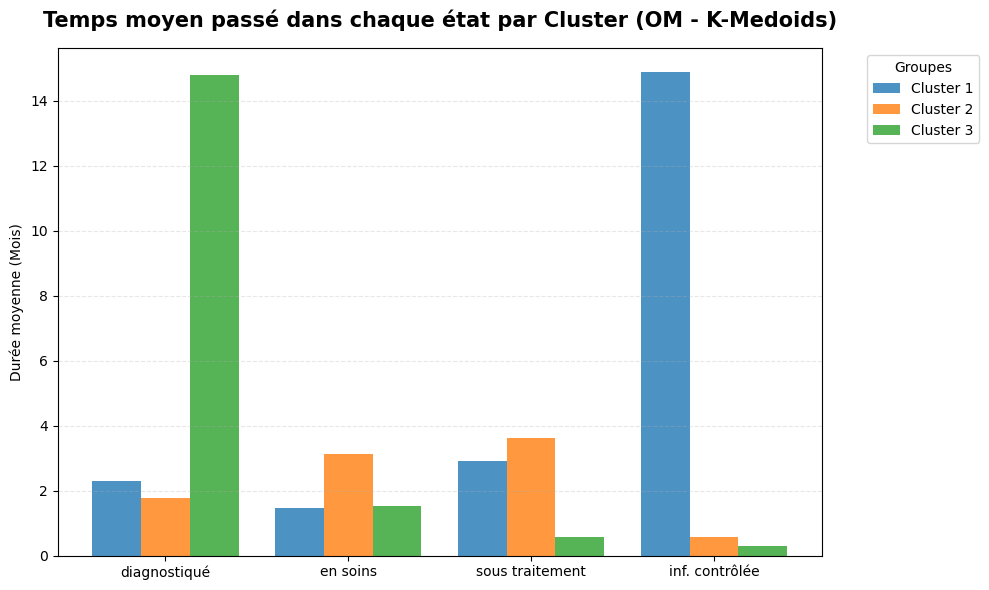

In [40]:
plot_mean_time(tca, clusters=kmedoids_labels_OM, title="Temps moyen passé dans chaque état par Cluster (OM - K-Medoids)")

Ici, on est dans le meme cas que précedemment, mais avec les clusters 1 et 3 qui sont inversés.

## 5.3. Trajectoires médoïdes :
On peut aussi introduire l'équivalent à la fonction `seqrep` de Traminer, elle extrait dans chaque cluster la trajectoire d'un patient qui est le "meilleur" medoid, elle calcule le pourcentage de patients dans le cluster qui ont un parcours similaire. On utilisera cette fonction `extract_rep_seq` pour comparer entre eux nos clusters avec cette fois-ci des trajectoires réelles ($\neq$ trajectoires modales), et cela permet aussi de vérifier que nos patients dans chaque clusters sont assez proches de leurs médoids.

In [77]:
def extract_representative_sequences(df_sequences, distance_matrix, cluster_labels, coverage_threshold):
    """
    Identifie la séquence médoïde de chaque cluster et calcule sa représentativité.
    
    Paramètres:
    -----------
    df_sequences : DataFrame
        Le dataframe contenant uniquement les séquences (sans la colonne d'index patient).
    distance_matrix : ndarray
        La matrice de distance.
    cluster_labels : array-like
        Les labels de cluster affectés à chaque patient (taille N).
    coverage_threshold : float
        La distance maximale acceptable pour dire qu'un patient est "représenté" par le médoïde.
        
    Retourne:
    ---------
    dict : Un dictionnaire contenant les infos du médoïde pour chaque cluster.
    """
    unique_clusters = np.unique(cluster_labels)
    results = {}
    
    for cluster in unique_clusters:
        idx_cluster = np.where(cluster_labels == cluster)[0]
        n_patients = len(idx_cluster)
        
        # Extraire la sous-matrice de distance uniquement pour ce cluster
        sub_matrix = distance_matrix[np.ix_(idx_cluster, idx_cluster)]
        
        # Trouver le médoïde (celui dont la somme des distances aux autres est minimale)
        sum_distances = sub_matrix.sum(axis=1)
        medoid_relative_idx = np.argmin(sum_distances) # Index dans la sous-matrice
        medoid_absolute_idx = idx_cluster[medoid_relative_idx] # Index dans le jeu de données global
        
        # Calculer le taux de couverture
        distances_to_medoid = sub_matrix[medoid_relative_idx]
        covered_count = np.sum(distances_to_medoid <= coverage_threshold)
        coverage_rate = (covered_count / n_patients) * 100
        
        # Stocker les résultats
        results[cluster] = {
            'medoid_index': medoid_absolute_idx,
            'sequence': df_sequences.iloc[medoid_absolute_idx].values,
            'n_patients': n_patients,
            'coverage_rate': coverage_rate,
            'covered_count': covered_count
        }
        
    return results


def plot_representative_sequences(tca, rep_seq_results, title="Séquences Représentatives (Médoïdes)"):
    """
    Affiche les séquences représentatives avec leur taux de couverture.
    Paramètres:
    -----------
    tca : TCA object
    rep_seq_results : dict
        Dictionnaire contenant les informations des séquences représentatives pour chaque cluster.
    title : str
        Le titre du graphique. 
    """
    clusters = list(rep_seq_results.keys())
    n_clusters = len(clusters)
    
    fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 1.2 * n_clusters), sharex=True)
    if n_clusters == 1: axes = [axes]
        
    colors = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(tca.alphabet))]
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_bad(color='lightgray')
    bounds = np.arange(len(tca.alphabet) + 1) - 0.5
    norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
    
    state_to_idx = {state: idx for idx, state in enumerate(tca.alphabet)}
    
    for idx, cluster in enumerate(clusters):
        ax = axes[idx]
        info = rep_seq_results[cluster]
        
        # Convertir la séquence en numérique pour l'affichage
        seq_numeric = np.array([state_to_idx.get(s, np.nan) for s in info['sequence']])
        matrix = seq_numeric.reshape(1, -1).astype(float) # Format requis pour imshow
        
        # Affichage
        ax.imshow(matrix, aspect='auto', cmap=custom_cmap, norm=norm, interpolation='none')
        
        # Labels axe Y : Nom du cluster et couverture
        label = (f"Cluster {cluster}\n"
                 f"Couverture: {info['coverage_rate']:.1f}%\n"
                 f"({info['covered_count']}/{info['n_patients']} patients)")
        
        ax.set_yticks([0])
        ax.set_yticklabels([label], fontsize=10)
        ax.tick_params(axis='y', length=0)
        
    df_time_base = tca.data.drop(columns=[tca.index_col])
    x_labels = df_time_base.columns
    step = 3
    axes[-1].set_xticks(np.arange(0, len(x_labels), step))
    axes[-1].set_xticklabels(x_labels[::step], rotation=45, ha='right')
    axes[-1].set_xlabel("Temps")

    patches = [mpatches.Patch(color=colors[i], label=tca.states[i]) for i in range(len(tca.alphabet))]
    patches.append(mpatches.Patch(color='lightgray', label="Pas de donnée"))
    fig.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.15), 
               ncol=min(len(tca.states), 5), frameon=False)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

Le choix de `coverage_threshold` dépend de la matrice de couts, si une substitution coute 1, un seul de 5 par exemple signifie qu'on considère qu'un patient est représenté par la séquence de médoide s'il y a au maximum l'équivalent de 5 mois de différence/substitution entre lui et le médoïde.

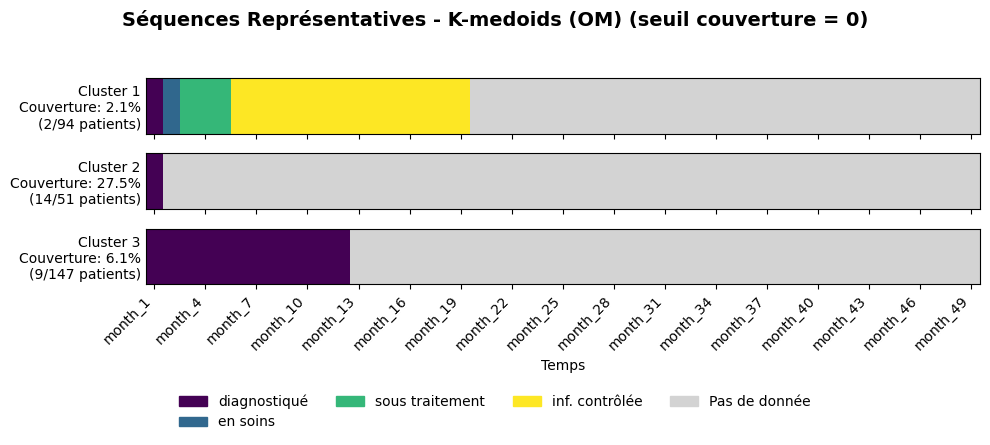

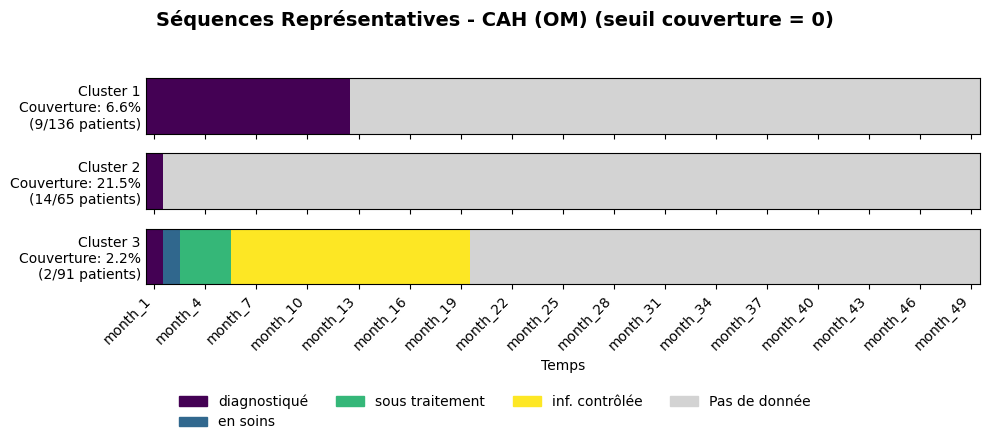

In [78]:
df_seq = tca.data.drop(columns=[tca.index_col])

seuil_couverture0 = 0

resultats_rep_kmed = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=kmedoids_labels_OM, 
        coverage_threshold=seuil_couverture0
    )

resultats_rep_cah = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=clusters_OM, 
        coverage_threshold=seuil_couverture0
    )

plot_representative_sequences(tca, resultats_rep_kmed, title=f"Séquences Représentatives - K-medoids (OM) (seuil couverture = {seuil_couverture0})")
plot_representative_sequences(tca, resultats_rep_cah, title=f"Séquences Représentatives - CAH (OM) (seuil couverture = {seuil_couverture0})")

Lorsqu'on a un seuil de couverture de 0, c'est à dire qu'on cherche les trajectoires du cluster qui sont identiques à celle du médoïde, relativement à la distance OM, on remarque que les cluster 2 sont assez bien représenté, mais on cherche un seuil de couverture qui n'est pas trop grand, mais qui maximise le taux de couverture pour tous les clusters.

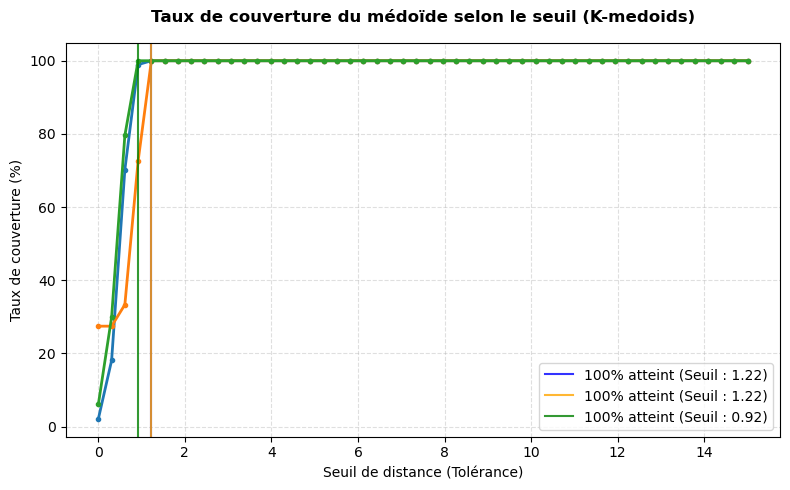

In [79]:
# Pour K-medoids (DTW) :
seuils_a_tester = np.linspace(0, 15, 50) 
taux1 = []
taux2 = []
taux3 = []

for seuil in seuils_a_tester:
    res = extract_representative_sequences(df_seq, distance_matrix_OM, kmedoids_labels_OM, coverage_threshold=seuil)
    taux1.append(res[1]['coverage_rate'])
    taux2.append(res[2]['coverage_rate'])
    taux3.append(res[3]['coverage_rate'])

taux1_array = np.array(taux1)
taux2_array = np.array(taux2)
taux3_array = np.array(taux3)

indices1_100 = np.where(taux1_array >= 99.9)[0]
indices2_100 = np.where(taux2_array >= 99.9)[0]
indices3_100 = np.where(taux3_array >= 99.9)[0]

seuil1_100 = None
if len(indices1_100) > 0:
    premier_index_100 = indices1_100[0]
    seuil1_100 = seuils_a_tester[premier_index_100]

seuil2_100 = None
if len(indices2_100) > 0:
    premier_index_100 = indices2_100[0]
    seuil2_100 = seuils_a_tester[premier_index_100]

seuil3_100 = None
if len(indices3_100) > 0:
    premier_index_100 = indices3_100[0]
    seuil3_100 = seuils_a_tester[premier_index_100]

plt.figure(figsize=(8, 5))
plt.plot(seuils_a_tester, taux1_array, marker='.', linestyle='-', color='tab:blue', linewidth=2)
plt.plot(seuils_a_tester, taux2_array, marker='.', linestyle='-', color='tab:orange', linewidth=2)
plt.plot(seuils_a_tester, taux3_array, marker='.', linestyle='-', color='tab:green', linewidth=2)

if seuil1_100 is not None:
    plt.axvline(x=seuil1_100, color='blue', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil1_100:.2f})')


if seuil2_100 is not None:
    plt.axvline(x=seuil2_100, color='orange', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil2_100:.2f})')

if seuil3_100 is not None:
    plt.axvline(x=seuil3_100, color='green', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil3_100:.2f})')

plt.title("Taux de couverture du médoïde selon le seuil (K-medoids)", fontweight='bold', pad=15)
plt.xlabel("Seuil de distance (Tolérance)")
plt.ylabel("Taux de couverture (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Pour les K-medoids, à partir d'un seuil de 1,22, on atteit une couverture de 100% pour tous les clusters. Cela veut dire, que pour chaque cluster, pour tous les patients, la distance la plus grande entre la trajectoire d'un patient du cluster et celle du médoïde est de 1.22 relativement à la distance OM.

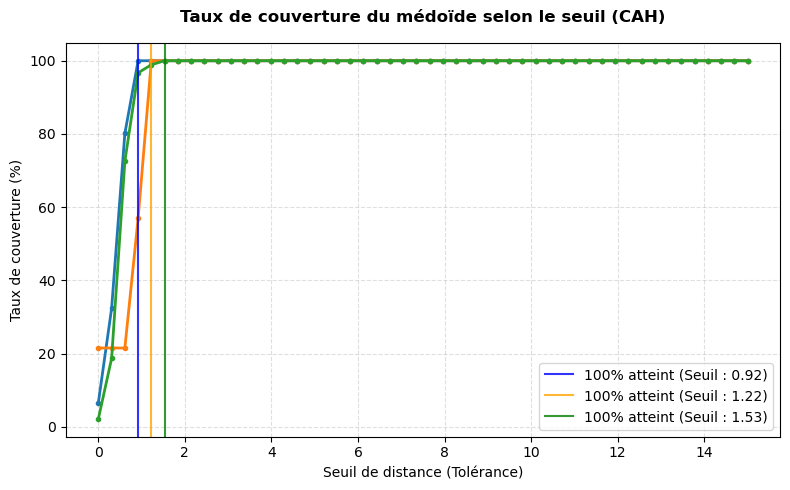

In [80]:
# Pour CAH (DTW) :
seuils_a_tester = np.linspace(0, 15, 50) 
taux1 = []
taux2 = []
taux3 = []

for seuil in seuils_a_tester:
    res = extract_representative_sequences(df_seq, distance_matrix_OM, clusters_OM, coverage_threshold=seuil)
    taux1.append(res[1]['coverage_rate'])
    taux2.append(res[2]['coverage_rate'])
    taux3.append(res[3]['coverage_rate'])

taux1_array = np.array(taux1)
taux2_array = np.array(taux2)
taux3_array = np.array(taux3)

indices1_100 = np.where(taux1_array >= 99.9)[0]
indices2_100 = np.where(taux2_array >= 99.9)[0]
indices3_100 = np.where(taux3_array >= 99.9)[0]

seuil1_100 = None
if len(indices1_100) > 0:
    premier_index_100 = indices1_100[0]
    seuil1_100 = seuils_a_tester[premier_index_100]

seuil2_100 = None
if len(indices2_100) > 0:
    premier_index_100 = indices2_100[0]
    seuil2_100 = seuils_a_tester[premier_index_100]

seuil3_100 = None
if len(indices3_100) > 0:
    premier_index_100 = indices3_100[0]
    seuil3_100 = seuils_a_tester[premier_index_100]

plt.figure(figsize=(8, 5))
plt.plot(seuils_a_tester, taux1_array, marker='.', linestyle='-', color='tab:blue', linewidth=2)
plt.plot(seuils_a_tester, taux2_array, marker='.', linestyle='-', color='tab:orange', linewidth=2)
plt.plot(seuils_a_tester, taux3_array, marker='.', linestyle='-', color='tab:green', linewidth=2)

if seuil1_100 is not None:
    plt.axvline(x=seuil1_100, color='blue', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil1_100:.2f})')


if seuil2_100 is not None:
    plt.axvline(x=seuil2_100, color='orange', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil2_100:.2f})')

if seuil3_100 is not None:
    plt.axvline(x=seuil3_100, color='green', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil3_100:.2f})')

plt.title("Taux de couverture du médoïde selon le seuil (CAH)", fontweight='bold', pad=15)
plt.xlabel("Seuil de distance (Tolérance)")
plt.ylabel("Taux de couverture (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Pour CAH, à partir d'un seuil de 1,53, on atteit une couverture de 100%. Cela veut dire, que pour chaque cluster, pour tous les patients, la distance la plus grande entre la trajectoire d'un patient du cluster et celle du médoïde est de 1.53 (Cluster 3) relativement à la distance OM.

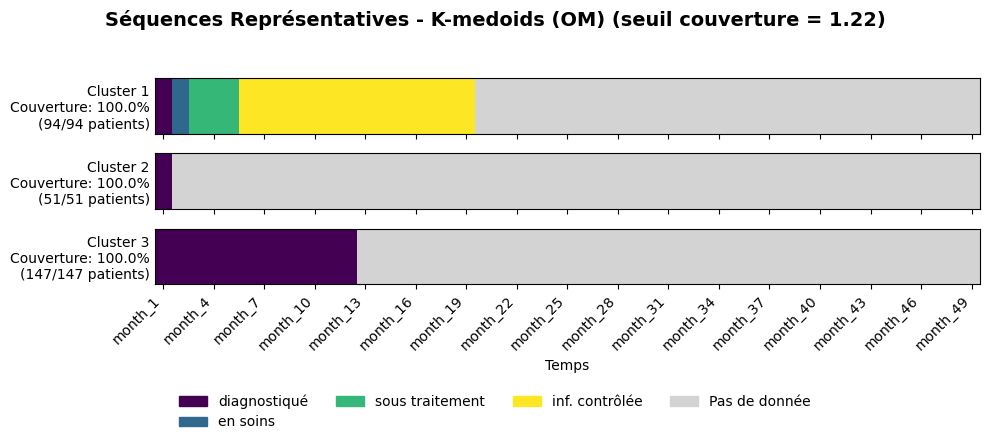

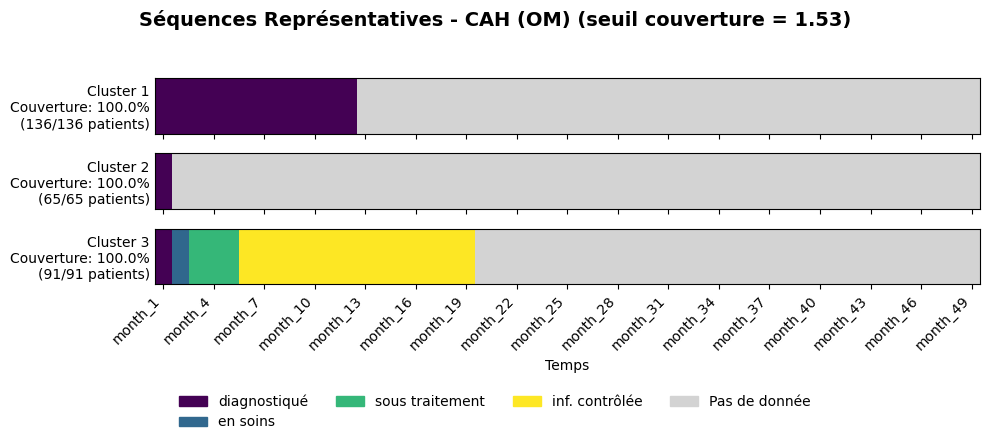

In [81]:
seuil_kmed = 1.22
seuil_cah = 1.53

resultats_rep_kmed = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=kmedoids_labels_OM, 
        coverage_threshold=seuil_kmed
    )

resultats_rep_cah = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=clusters_OM, 
        coverage_threshold=seuil_cah
    )

plot_representative_sequences(tca, resultats_rep_kmed, title=f"Séquences Représentatives - K-medoids (OM) (seuil couverture = {seuil_kmed})")
plot_representative_sequences(tca, resultats_rep_cah, title=f"Séquences Représentatives - CAH (OM) (seuil couverture = {seuil_cah})")

Avec ces seuils la, 100% des patients sont représentés par les médoïdes de leur cluster.

## 5.4. SeqTree

Cette méthode croise le profil des patients (age, sexe,...) avec leurs séquences temporelles. Il prend en entrée les covariables et cherche quelle variable sépare le mieux les patients en groupes avec des parcours de soins similaires.

In [48]:
def plot_trajectory_decision_tree(df_clinical, cluster_labels, max_depth=3, variables_label=None, titre="Arbre de décision des trajectoires cliniques"):
    """
    Entraîne et affiche un arbre de décision épuré pour voir quelles variables
    conduisent aux différents clusters (avec de vrais labels explicites).
    """
    X = df_clinical.copy()
    
    # 1. On traduit les chiffres en vrais mots (Homme, Femme, Pauvre...)
    if variables_label is not None:
        X = X.replace(variables_label)
        
    # 2. On crée les colonnes binaires (ex: sex_Femme) pour l'arbre
    X = pd.get_dummies(X)
        
    y = cluster_labels
    
    # Entraînement de l'arbre
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42, min_samples_leaf=0.05)
    clf.fit(X, y)
    
    # Visualisation
    plt.figure(figsize=(15, 8))
    
    feature_noms = X.columns.tolist()
    class_names = [f"Cluster {c}" for c in clf.classes_]
    
    annotations = plot_tree(
        clf, 
        feature_names=feature_noms,
        class_names=class_names,
        filled=True, 
        rounded=True, 
        fontsize=12,
        impurity=False
    )
    
    for text_obj in annotations:
        text = text_obj.get_text()
        lignes = text.split('\n')
        lignes_new = []
        
        for ligne in lignes:
            if "samples" in ligne or "value" in ligne:
                continue
                
            if "<=" in ligne:
                col_name = ligne.split(" <= ")[0]
                
                if "_" in col_name and "0.5" in ligne:
                    var_name, modalite = col_name.split("_", 1)
                    lignes_new.append(f"{var_name} : {modalite} ?")
                    # Ajout de la boussole anti-erreur
                    lignes_new.append("<- Non  | Oui ->")
                else:
                    lignes_new.append(f"{ligne} ?")
            else:
                lignes_new.append(ligne)
                
        nouveau_texte = '\n'.join(lignes_new)
        text_obj.set_text(nouveau_texte)
        text_obj.set_fontweight('bold')

    plt.title(titre, fontsize=16, pad=20, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return clf

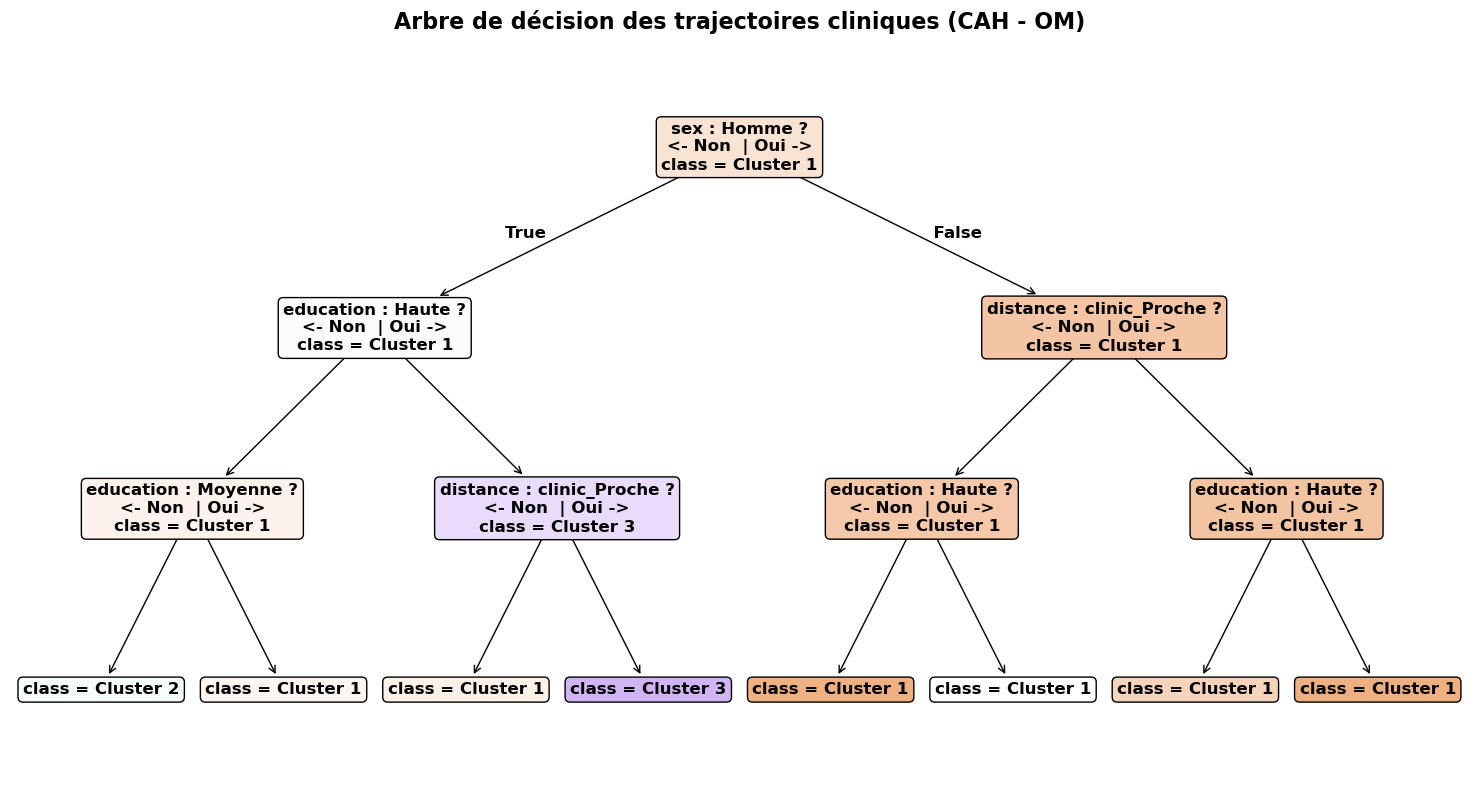

In [49]:
arbre_cah = plot_trajectory_decision_tree(
    df_clinical=col_stats, 
    cluster_labels=clusters_OM,
    max_depth=3,  # On limite à 3 étages
    variables_label=label_var,
    titre="Arbre de décision des trajectoires cliniques (CAH - OM)"
)

Plus le cluster à la fin est foncé, plus ce profil a de chances d'être dans ce cluster.

* CAH :
    * Les femmes proches de la clinique avec une education haute ont plus de chances d'être dans le cluster 3.
    * Les femmes avec une éducation basse ont plus de chances d'être dans le cluster 2.
    * Les hommes qui sont éloignés de la clinique et qui ont une basse ou moyenne éducation ont plus de chances d'être dans le cluster 1.

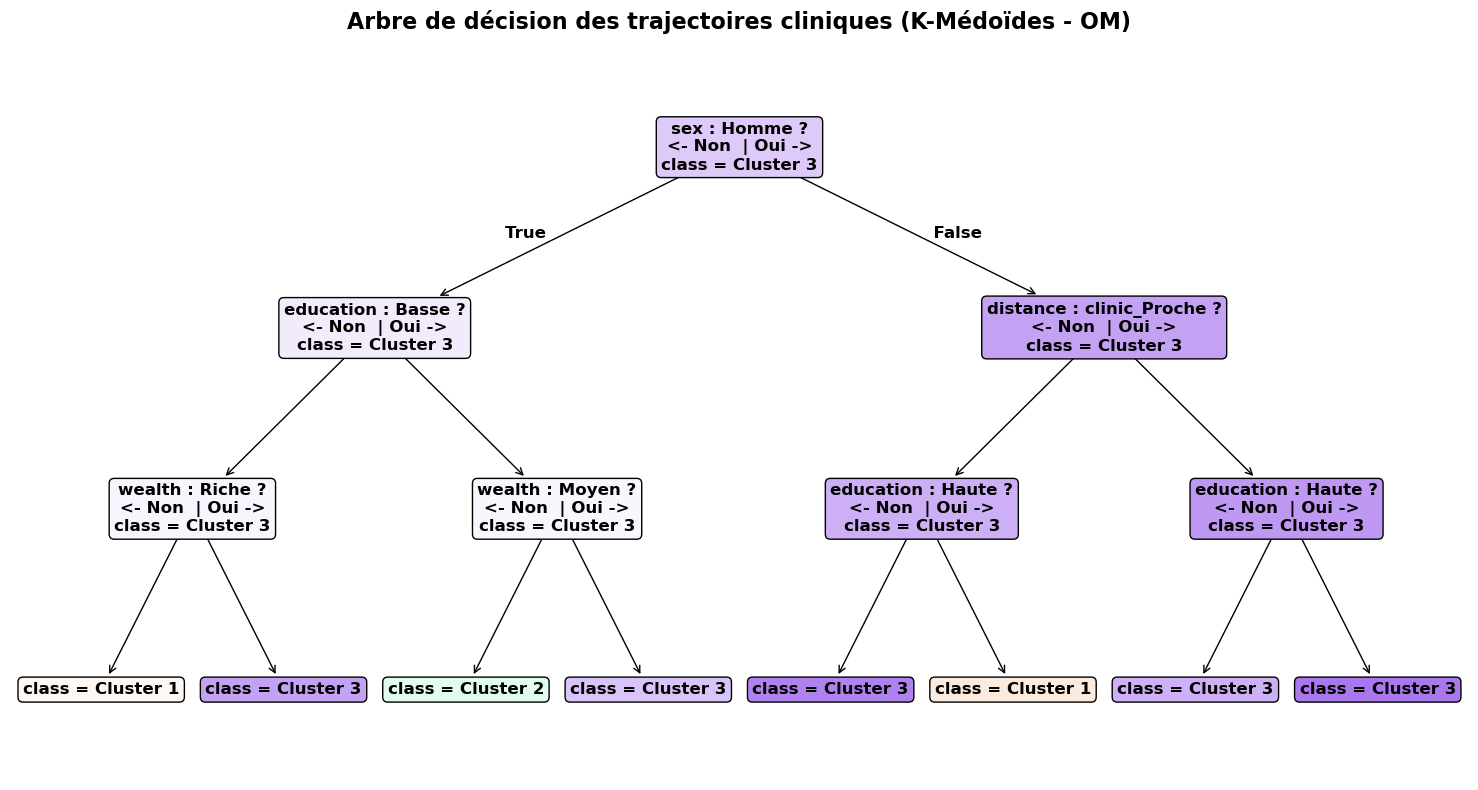

In [50]:
arbre_kmed = plot_trajectory_decision_tree(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM,
    max_depth=3,
    variables_label=label_var,
    titre="Arbre de décision des trajectoires cliniques (K-Médoïdes - OM)"
)

* K-Medoids :
    * Les hommes avec une basse ou moyenne éducation ont plus de chances d'être dans le cluster 3.
    * Les femmes avec une éducation basse et riches ont plus de chances d'être dans le cluster 2.
    * Les hommes avec une hauteéducation et qui sont loins de la cliniques ont plus de chances d'être dans le cluster 1.

## 5.5. Analyse du temps jusqu'à l'infection controlée (S)
On peut visualiser la rapidité à laquelle les patients de chaque cluster atteignent l'état S. A chaque mois, quel pourcentage de patients de chaque cluster a atteint l'état S.

Pour ce faire, on utilise a librairie `lifelines`.

In [51]:
def plot_time_to_event(df_sequences, cluster_labels, target_state='S', time_unit="Mois", titre="Temps avant d'atteindre l'état S par cluster"):
    """
    Affiche les courbes de Kaplan-Meier (Incidence Cumulée) pour comparer 
    la rapidité avec laquelle chaque cluster atteint l'état S.

    Paramètres :
    -----------
    df_sequences : pd.DataFrame
        DataFrame contenant les séquences d'états (sans la colonne d'identifiant).
    cluster_labels : array-like
        Les labels de cluster pour chaque patient.
    target_state : str, optionnel
        L'état d'intérêt pour l'analyse de survie (défaut : 'S').
    time_unit : str, optionnel
        L'unité de temps à afficher sur l'axe X (défaut : "Mois").
    """
    T = [] # Temps jusqu'à l'événement (ou temps de suivi max si non atteint)
    E = [] # 1 si l'état S est atteint, 0 sinon
    
    max_time = df_sequences.shape[1]
    
    # Extraction des temps d'atteinte pour chaque patient
    for i in range(len(df_sequences)):
        seq = df_sequences.iloc[i].values
        # Première occurrence de l'état S
        indices = np.where(seq == target_state)[0]
        
        if len(indices) > 0:
            T.append(indices[0]) # Le temps est l'index de la première occurrence
            E.append(1)          # L'événement s'est produit
        else:
            T.append(max_time)   # N'a jamais atteint l'état pendant le suivi
            E.append(0)          # L'événement ne s'est pas produit
            
    plt.figure(figsize=(10, 6))
    kmf = KaplanMeierFitter()
    
    unique_clusters = np.unique(cluster_labels)
    
    for cluster in unique_clusters:
        # Filtrer les patients appartenant à ce cluster
        idx = (cluster_labels == cluster)
        T_cluster = np.array(T)[idx]
        E_cluster = np.array(E)[idx]
        
        kmf.fit(T_cluster, event_observed=E_cluster, label=f"Cluster {cluster}")
        
        # plot_cumulative_density affiche la proportion qui a ATTEINT l'état (monte de 0 à 1)
        kmf.plot_cumulative_density(ci_show=False, linewidth=2.5)

    # 4. Esthétique du graphique
    plt.title(titre, fontsize=15, pad=15, fontweight='bold')
    plt.xlabel(f"Temps écoulé ({time_unit})", fontsize=12)
    plt.ylabel(f"Proportion de patients dans l'état '{target_state}'", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # On force l'axe Y à aller de 0% à 100%
    plt.ylim(0, 1.05)
    yticks = plt.gca().get_yticks()
    plt.gca().set_yticks(yticks)
    plt.gca().set_yticklabels([f"{int(x*100)}%" for x in yticks])
    
    plt.legend(
        title="Clusters", 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15), 
        ncol=min(len(unique_clusters), 5), 
        frameon=True
        )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

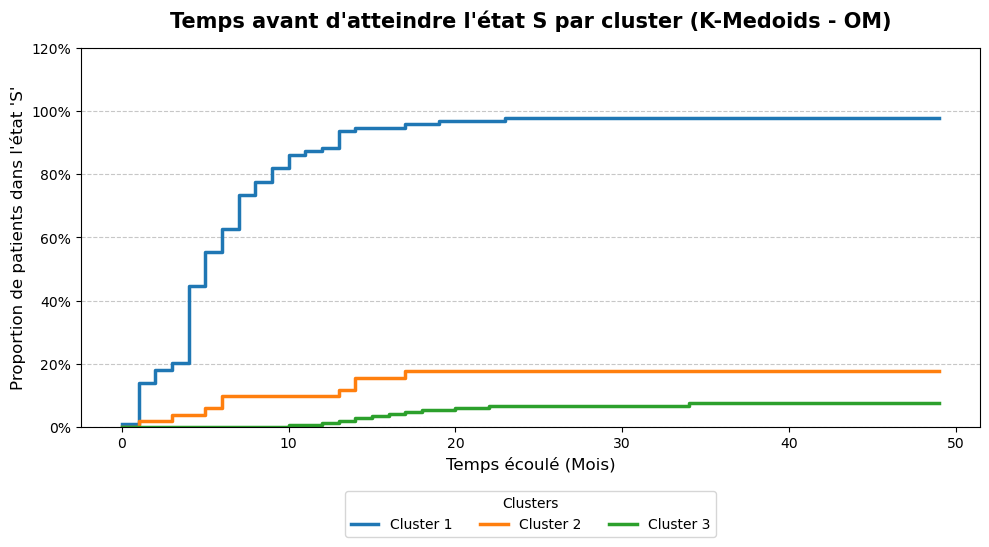

In [52]:
df_seq = tca.data.drop(columns=[tca.index_col])

plot_time_to_event(
    df_sequences=df_seq, 
    cluster_labels=kmedoids_labels_OM, 
    target_state='S',
    titre=f"Temps avant d'atteindre l'état S par cluster (K-Medoids - OM)"
)

* K-medoids :
    * La majorité patients du cluster 3 n'atteignent jamais l'état d'infection contrôlée, ils sont toujours à l'état de diagnostic.
    * Moins de 20% des patients du cluster 2 sont à l'état S, cela stagne à partir de 17 mois environ.
    * On arrive très rapidement proches des 100% de patients à l'état d'infection contrôlée pour le cluster 1.


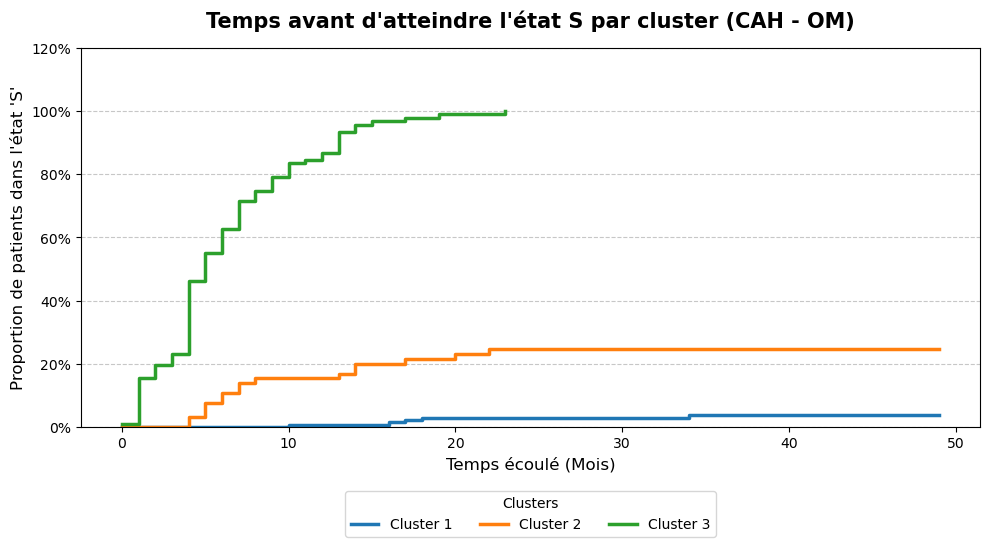

In [53]:
plot_time_to_event(
    df_sequences=df_seq, 
    cluster_labels=clusters_OM, 
    target_state='S',
    titre=f"Temps avant d'atteindre l'état S par cluster (CAH - OM)"
)

* CAH :
    * La majorité des patients du cluster 1 n'atteignent jamais l'état d'infection contrôlée.
    * Un peu plus de 20% des patiets du cluster 2 finissent à l'état d'infection contrôlée, mais cela stagne au bout de 22 mois environ ici.
    * On arrive plus rapidement à presque 100% de patients à l'état d'infection contrôlée pour le cluster 3.

## 5.6. Projection des variables sur les clusters

Cette fonction permet de visualiser pour chaque variable la répartition des patients dans chaque cluster.

In [54]:
def plot_cluster_profiles(df_clinical, cluster_labels, variables_label=None, variables_to_plot=None):
    """
    Croise les variables avec les clusters pour 
    visualiser le profil exact de chaque groupe.
    
    Paramètres:
    -----------
    df_clinical : DataFrame
        Le dataframe contenant les variables statiques (Âge, Sexe, etc.).
    cluster_labels : array
        Les labels.
    variables_to_plot : list, optionnel
        Liste spécifique de colonnes à tracer. Si None, prend toutes les colonnes.
    """
    # On fusionne les variables cliniques avec l'étiquette du cluster
    df_analyse = df_clinical.copy()

    if variables_label is not None:
        df_analyse = df_analyse.replace(variables_label)

    df_analyse['Cluster'] = cluster_labels
    
    # Sélection des variables à analyser
    if variables_to_plot is None:
        variables_to_plot = [col for col in df_analyse.columns if col != 'Cluster']
        
    n_vars = len(variables_to_plot)
    n_cols = 2
    n_rows = (n_vars + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()
    
    # Boucle sur chaque variable pour créer le graphique
    for i, var in enumerate(variables_to_plot):
        crosstab = pd.crosstab(df_analyse['Cluster'], df_analyse[var], normalize='index') * 100
        
        # On trace un graphique en barres empilées
        crosstab.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='white')
        
        axes[i].set_title(f"Répartition de '{var}' par Cluster", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Clusters", fontsize=12)
        axes[i].set_ylabel("Pourcentage (%)", fontsize=12)
        
        # On force l'axe Y à aller jusqu'à 100%
        axes[i].set_ylim(0, 100)
        
        axes[i].legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        axes[i].tick_params(axis='x', rotation=0)
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

Profil des clusters selon K-medoids (OM) :


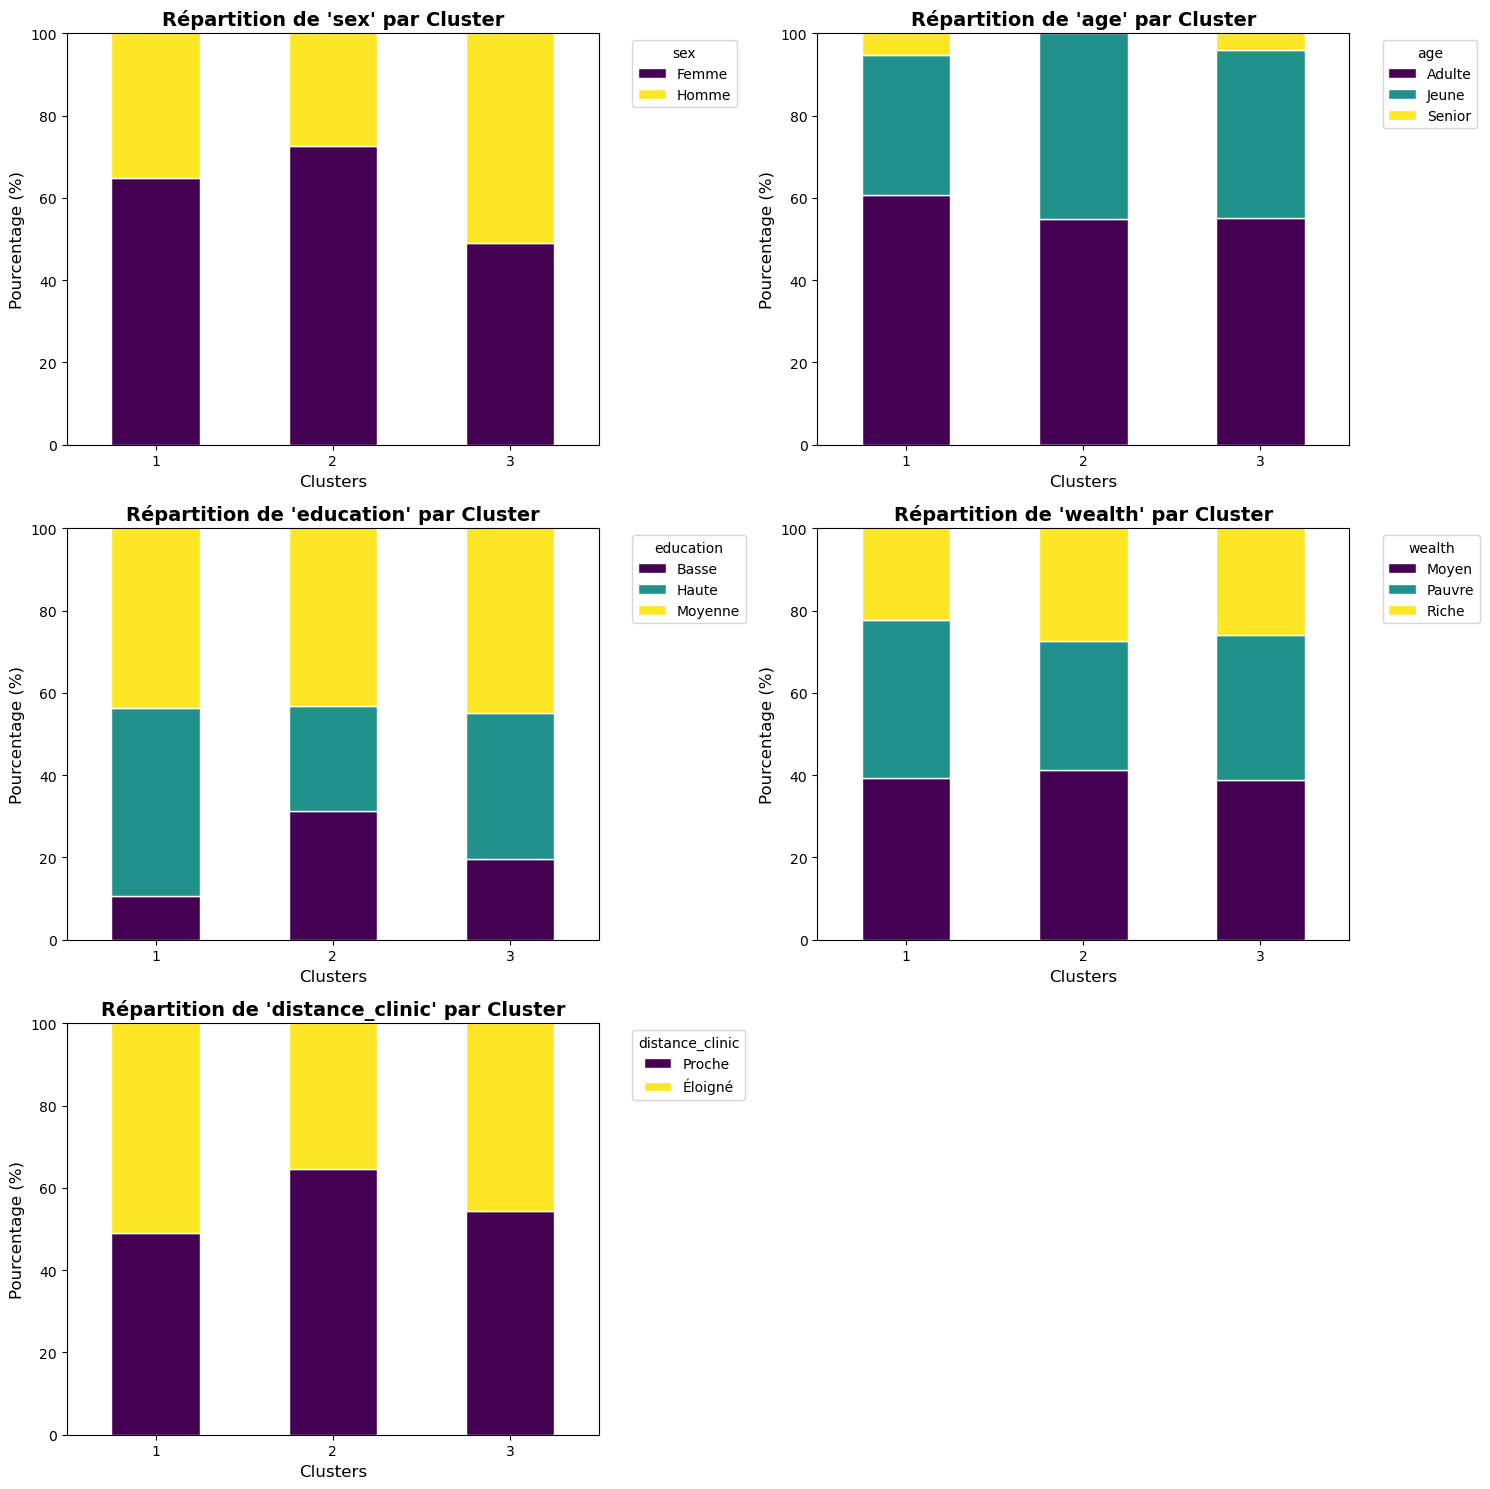

In [55]:
print("Profil des clusters selon K-medoids (OM) :")
plot_cluster_profiles(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM, variables_label=label_var
)

* K-medoid :
    * Majorité de femmes dans les clusters 1 et 2 / majorité d'hommes dans le cluster 3.
    * Peu de seniors dans les tous les clusters / majorité d'adultes dans tous les clusters / Pas de seniors dans le cluster 2.
    * Niveau d'étude moyen dans les 3 clusters / peu de niveau d'études bas pour le cluster 1 / peu de hautes études pour le cluster 2.
    * A peu près la même répartition de richesse pour les 3 clusters.
    * Majorité de patients proches dans le cluster 2.

Profil des clusters selon CAH (OM) :


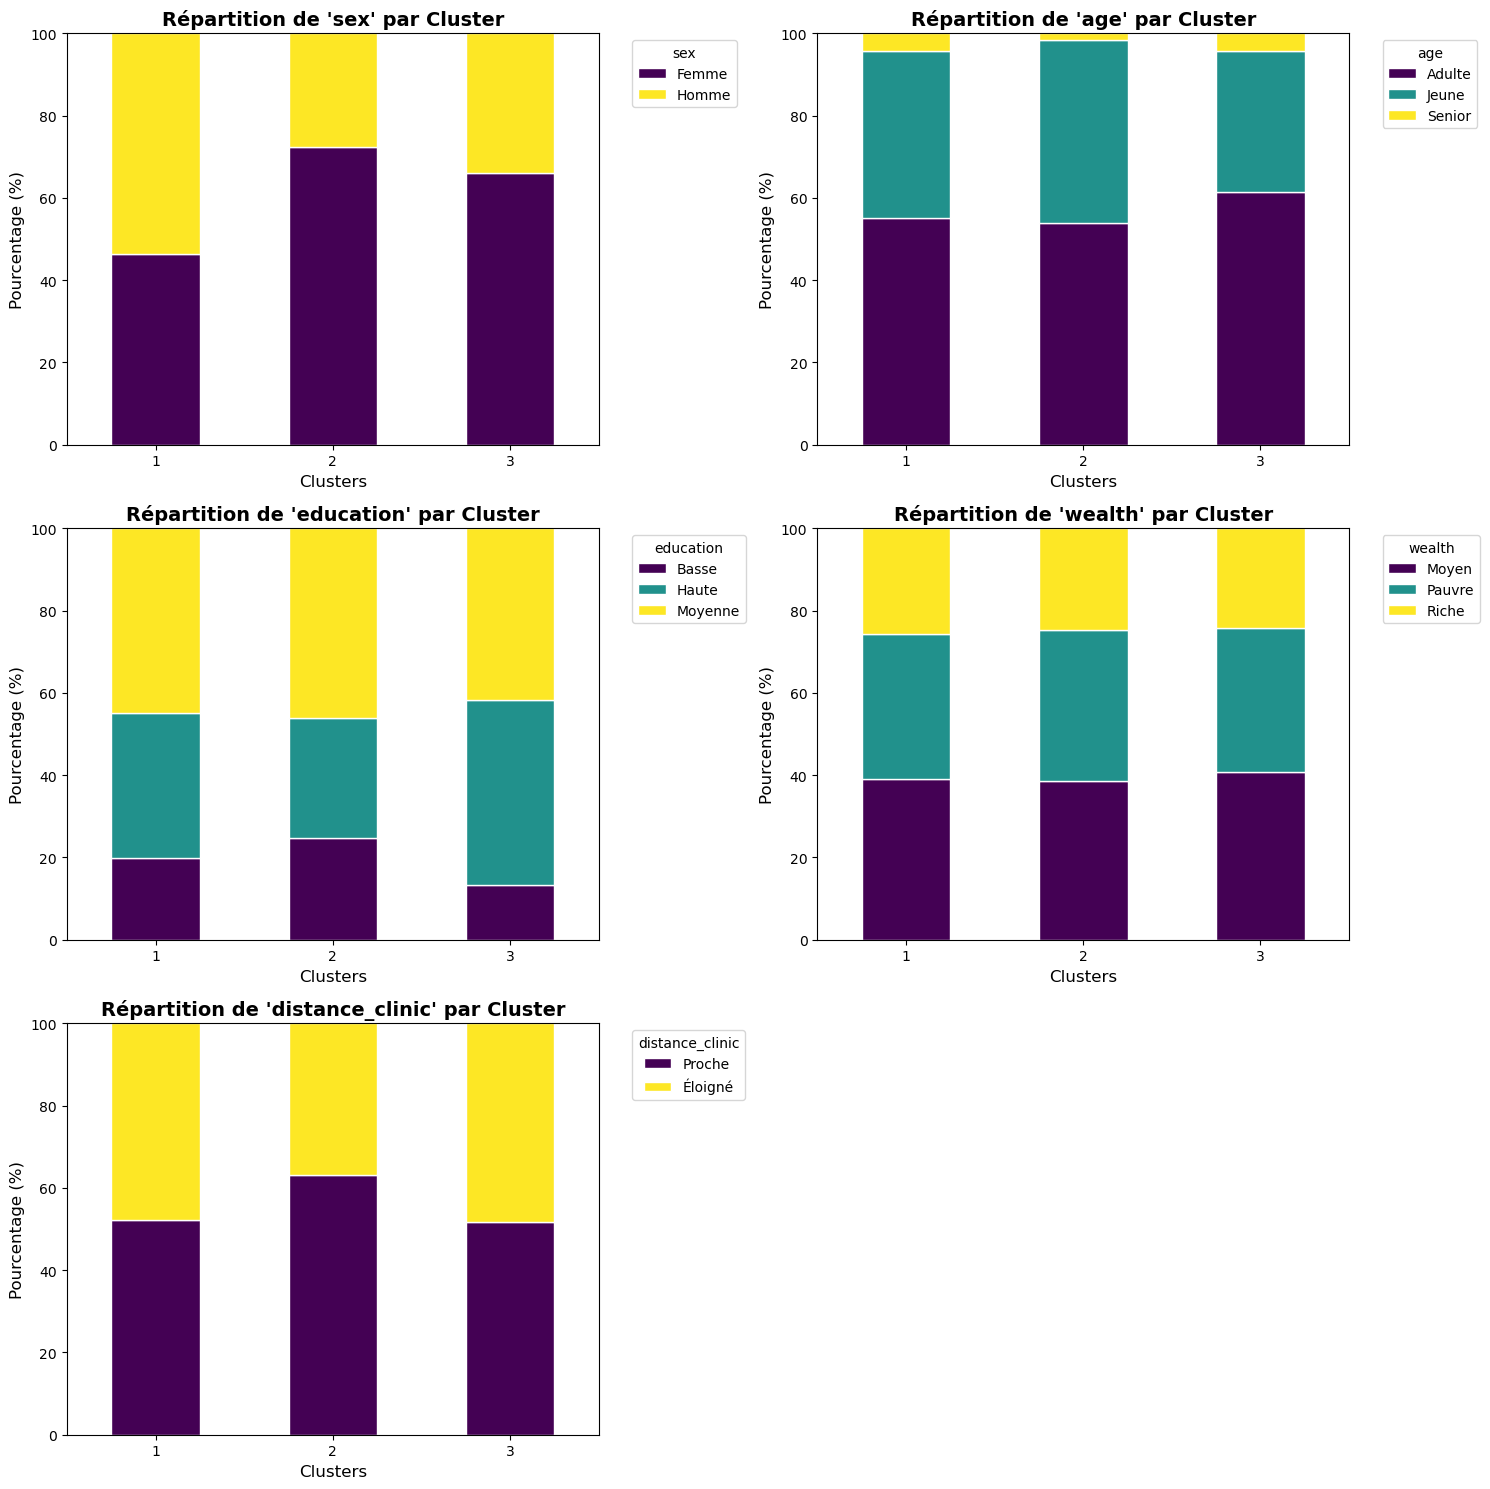

In [56]:
print("Profil des clusters selon CAH (OM) :")
plot_cluster_profiles(
    df_clinical=col_stats, 
    cluster_labels=clusters_OM, variables_label=label_var
)

* CAH :
    * Plus de femmes dans les clusters 2 et 3 / plus d'hommes dans le cluster 1
    * Seniors minimes dans le cluster 2
    * Haut et moyen niveaux d'éducation en majorité dans le cluster 3
    * Cluster 2 plus proche

Il serait intéressant de voir les différences avec la population totale.

## 5.7. Analyse des Transitions signatures
 Cette analyse identifie les passages d'un état à un autre qui séparent le plus les clusters. Cela permet de caractériser les clusters par les changements d'états que les patients ont le plus fréquemmebt.

In [57]:
def plot_signature_transitions(tca, clusters, n_top=6, titre="Transitions Signatures par Cluster"):
        """
        Identifie et affiche les transitions (A -> B) les plus fréquentes pour chaque cluster,
        en ignorant les transitions vides (nan -> nan).

        Paramètres:
        ----------- 
        tca : TCA object
            L'objet TCA contenant les données de séquences.
        clusters : array-like
            Les labels de cluster pour chaque patient.
        n_top : int, optionnel
            Le nombre de transitions à afficher par cluster (défaut : 6).
        """

        df_seqs = tca.data.drop(columns=[tca.index_col])
        unique_clusters = np.unique(clusters)
        
        # Extraire toutes les transitions (paires d'états consécutifs)
        all_transitions = []
        for i in range(len(df_seqs.columns) - 1):
            t1, t2 = df_seqs.columns[i], df_seqs.columns[i+1]
            # On crée la paire sous forme de chaîne
            pair = df_seqs[t1].astype(str) + " → " + df_seqs[t2].astype(str)
            all_transitions.append(pair)
        
        df_trans = pd.concat(all_transitions, axis=1)
        
        # Calculer la fréquence de chaque transition par cluster
        trans_counts = []
        for cluster in unique_clusters:
            cluster_mask = (clusters == cluster)
            # Compte les occurrences
            counts = df_trans[cluster_mask].apply(pd.Series.value_counts).sum(axis=1)
            counts = counts / cluster_mask.sum() # Normalisation
            counts.name = f"Cluster {cluster}"
            trans_counts.append(counts)
            
        df_diff = pd.concat(trans_counts, axis=1).fillna(0)
        
        # Enlève "nan -> nan", et aussi "D -> nan" ou "nan -> C"
        df_diff = df_diff[~df_diff.index.str.contains('nan', case=False)]
        
        # Calculer le score de discrimination (Écart-type)
        df_diff['score'] = df_diff.std(axis=1)
        top_transitions = df_diff.sort_values(by='score', ascending=False).head(n_top)
        top_transitions = top_transitions.drop(columns=['score'])

        # Affichage
        if top_transitions.empty:
            print("Aucune transition valide trouvée après filtrage des NaNs.")
            return

        top_transitions.plot(kind='barh', figsize=(10, 8), width=0.8, edgecolor='black')
        plt.title(titre, fontsize=15, fontweight='bold')
        plt.xlabel("Fréquence moyenne par patient")
        plt.ylabel("Type de Transition")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.legend(title="Clusters")
        plt.tight_layout()
        plt.show()

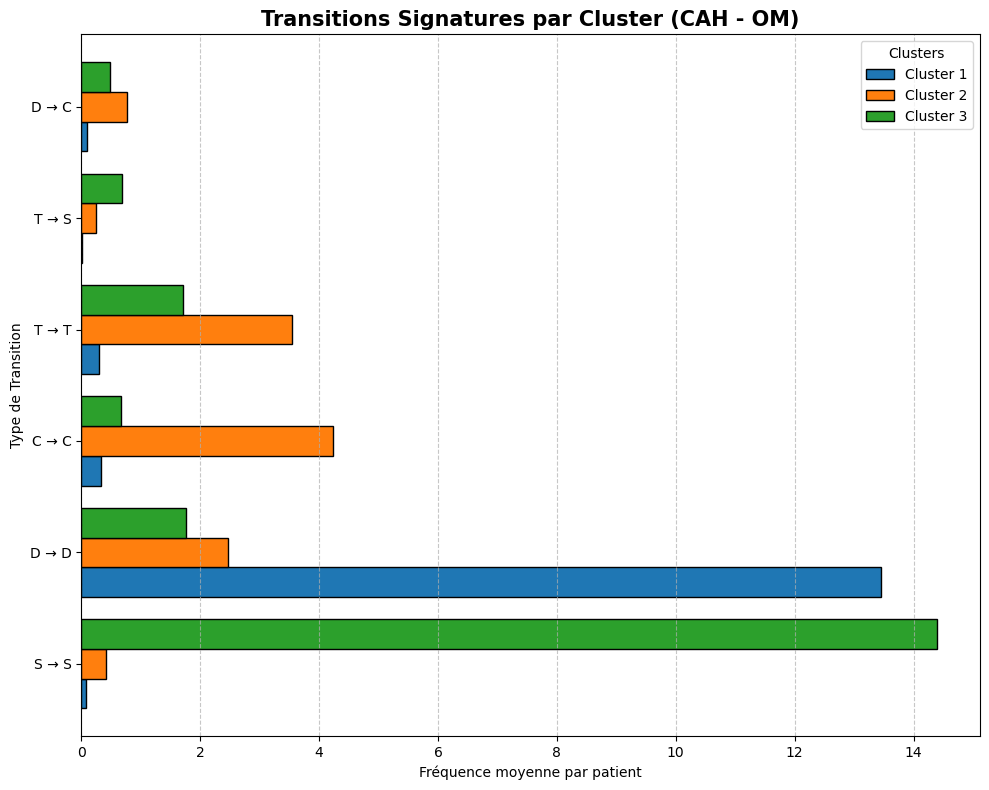

In [58]:
plot_signature_transitions(tca, clusters_OM, n_top=6, titre="Transitions Signatures par Cluster (CAH - OM)")

* Pour le cluster 1, on a une signature précise, on reste à l'état D.
* Pour le cluster 2, on n'a pas vraiment de signatures, on traverse un peu tous les états, mais on est majoritairement dans les états T et C
* Pour le cluster 3, on a en majorité la transition S->S

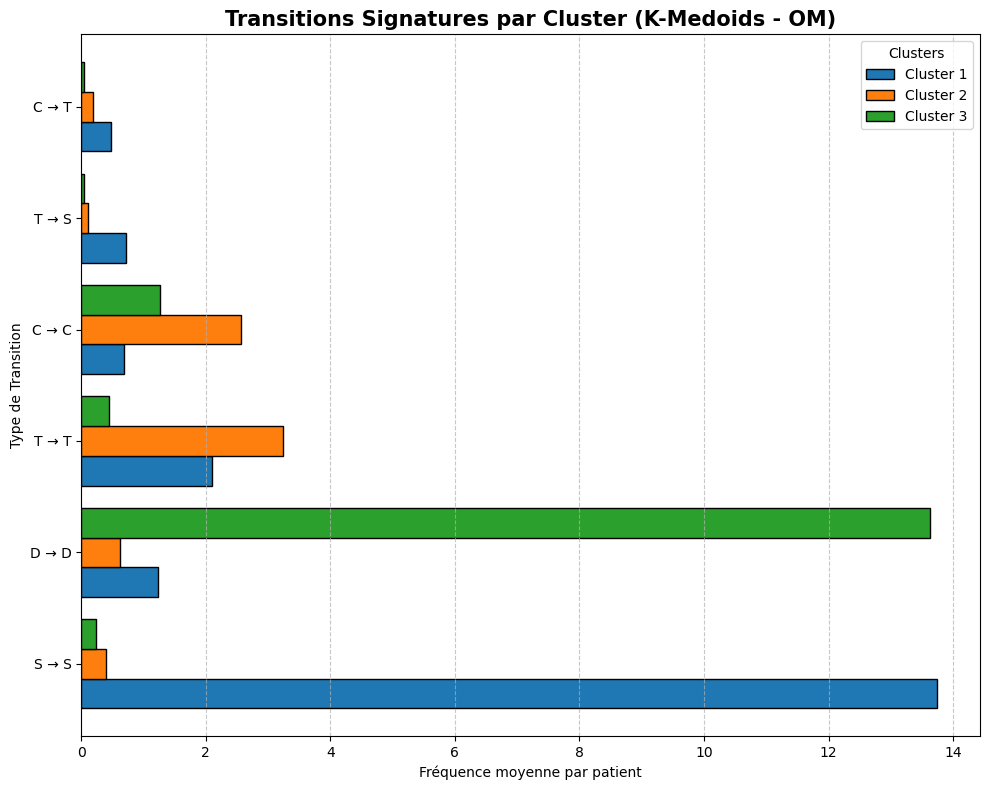

In [59]:
plot_signature_transitions(tca, kmedoids_labels_OM, n_top=6, titre="Transitions Signatures par Cluster (K-Medoids - OM)")

* La signature du cluster 3 est D->D.
* La signature du cluster 3 semble etre S->S
* Le cluster 2 passe par tous les états.

## 5.8. Trajectoires les plus éloignées


In [82]:
def plot_extreme_trajectories(tca, clusters, distance_matrix, title="Trajectoires Médoïdes vs Extrêmes par cluster"):
    """
    Affiche la trajectoire du médoïde et celle de la trajectoire la plus éloignée pour chaque cluster.

    Paramètres:
    ------------
    tca : TCA object
        L'objet TCA contenant les données de séquences.
    clusters : array-like
        Les labels de cluster pour chaque patient.
    distance_matrix : ndarray
        La matrice de distance utilisée pour le clustering (doit être dans le même ordre que les patients de tca.data).
    title : str
        Le titre du graphique.
    """
    unique_clusters = np.unique(clusters)
    df_seqs = tca.data.drop(columns=[tca.index_col])
    time_points = df_seqs.columns
    n_clusters = len(unique_clusters)

    state_to_idx = {state: idx for idx, state in enumerate(tca.alphabet)}
    colors = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(tca.alphabet))]
    
    custom_cmap = mcolors.ListedColormap(colors)
    # NaNs en gris
    custom_cmap.set_bad(color='lightgray') 
    bounds = np.arange(len(tca.alphabet) + 1) - 0.5
    norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

    fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 1.5 * n_clusters), sharex=True)
    if n_clusters == 1: axes = [axes]

    for i, cluster_label in enumerate(unique_clusters):
        ax = axes[i]
        
        # Isoler la matrice de distances de ce cluster spécifique
        cluster_indices = np.where(clusters == cluster_label)[0]
        sub_dist = distance_matrix[cluster_indices][:, cluster_indices]
        
        # Identifier le Médoïde
        dist_sums = sub_dist.sum(axis=1)
        medoid_local_idx = np.argmin(dist_sums)
        medoid_global_idx = cluster_indices[medoid_local_idx]
        
        # Identifier l'Extrême (la distance max par rapport au médoïde)
        dists_to_medoid = sub_dist[medoid_local_idx]
        extreme_local_idx = np.argmax(dists_to_medoid)
        extreme_global_idx = cluster_indices[extreme_local_idx]

        seq_medoid = df_seqs.iloc[medoid_global_idx].map(state_to_idx).astype(float).values
        seq_extreme = df_seqs.iloc[extreme_global_idx].map(state_to_idx).astype(float).values
        
        # Superposer les deux trajectoires (Extrême en haut, Médoïde en bas)
        matrix = np.vstack([seq_extreme, seq_medoid])
        
        ax.imshow(matrix, aspect='auto', cmap=custom_cmap, norm=norm, interpolation='none')
        
        ax.set_title(f"Cluster {cluster_label} (n={len(cluster_indices)})", fontweight='bold', fontsize=12)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Extrême", "Médoïde"], fontsize=11, fontweight='bold')
        
        ax.axhline(0.5, color='white', linewidth=3)
        ax.tick_params(axis='y', length=0) 

    step = 3 
    axes[-1].set_xticks(np.arange(0, len(time_points), step))
    axes[-1].set_xticklabels(time_points[::step], rotation=45, ha='right')
    axes[-1].set_xlabel("Temps (Mois)", fontsize=12)

    # 4. Légende
    patches = [mpatches.Patch(color=colors[i], label=tca.states[i]) for i in range(len(tca.alphabet))]
    patches.append(mpatches.Patch(color='lightgray', label="Pas de données"))
    fig.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.15), 
               ncol=min(len(tca.alphabet)+1, 5), frameon=False, fontsize=11)

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

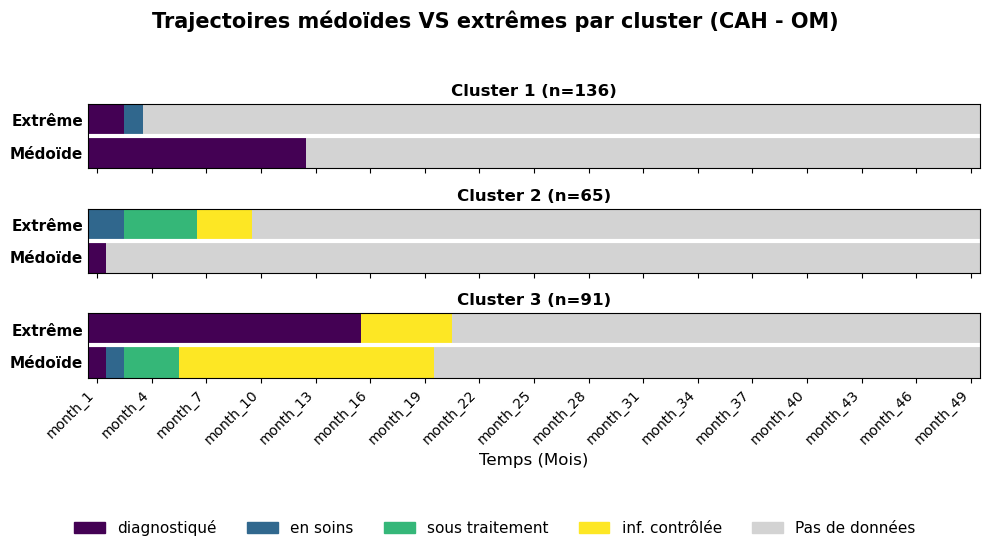

In [83]:
plot_extreme_trajectories(tca, clusters=clusters_OM, 
                              distance_matrix=distance_matrix_OM,
                              title="Trajectoires médoïdes VS extrêmes par cluster (CAH - OM)")

* Cluster 1 : La trajectoire la plus extrême se superpose avec la trajectoire du médoïde au début, elle passe ensuite en soins mais on n'a plus de données, le médoïde représente donc assez bien même les trajectoires les plus atypiques du cluster.
* Cluster 2 : La trajectoire la plus différente du médoïde est celle d'un patient qui est rapidement passé à l'état d'infection contrôlée avant de ne plus avoir de données. Le médoïde du cluster n'avait rapidement plus de données donc la trajecoire médoïde n'est pas tracée.
* Cluster 3 : Ici la trajectoire la plus éloignée est celle d'un patient qui était à l'état de diagnostic au départ, de passer rapidement à l'état d'infection contrôlée, toutefois il reste assez proche de la trajectoire médoïde, en effet le médoïde passe rapidement lui aussi à l'état d'infection contrölée.

Dans ce cas, les clusters sont assez bien représentés par leurs médoïdes, même les trajectoires les plus éloignées s'en rapprochent.
Mais le medoide du cluster 1 est presque le meme que celui du cluster 2.

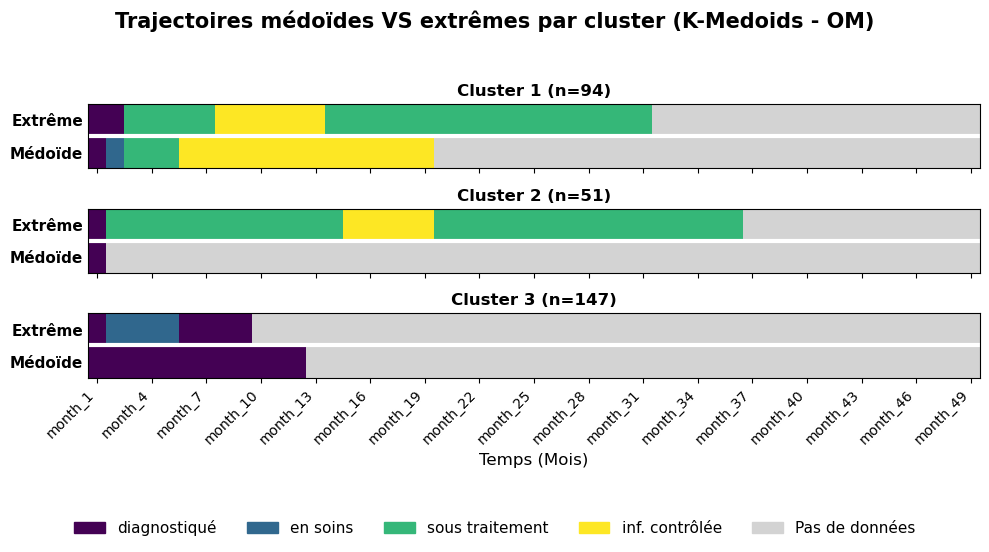

In [84]:
plot_extreme_trajectories(tca, clusters=kmedoids_labels_OM, 
                              distance_matrix=distance_matrix_OM,
                              title="Trajectoires médoïdes VS extrêmes par cluster (K-Medoids - OM)")

* Cluster 1 : Dans ce cluster, le médoïde passe par plusieurs états, mais est en majorité à l'état d'infection controlée, le patient le plus éloignée a passé lui aussi quelques mois à l'état d'infection contrôlée.
* Cluster 2 : Ici, on voit que dans le cluster où on a une majorité de patients en soins et en traitements,ce patient a alterné entre S et T, mais il ne suit pas le médoïde qui avait peu de données
* Cluster 3 : la trajectoire la plus éloignée est celle d'un patient qui était en diagnostic au départ, avant de passer à l'état de soins, et de revenir à diagnostic puis de ne plus avoir de données, toutefois il reste assez proche de la trajectoire médoïde, en effet le médoïde reste à l'état de diagnostic.

Les médoïdes représentent assez bien les patients dans leurs clusters, sauf le cluster 2 qui a un médoïde avec assez peu de données.
Ici, aussi le médoide du cluster 2 ressemble à celui du cluster 3.

## 5.9. Résumé des clusters

In [63]:
def summarize_clusters(tca, clusters, change_stab=2):
        """
        Génère un résumé de chaque cluster.

        Paramètres:
        -----------
        tca : TCA object
        clusters : array-like   
            Les labels de cluster pour chaque patient.
        change_stab : int, optionnel
            Seuil de nombre de changements d'états pour qualifier un cluster d'instable (défaut : 2).
        """
        unique_clusters = np.unique(clusters)
        df_seqs = tca.data.drop(columns=[tca.index_col])
        total_n = len(clusters)
        
        all_trans = []
        for i in range(len(df_seqs.columns) - 1):
            pair = df_seqs.iloc[:, i].astype(str) + " → " + df_seqs.iloc[:, i+1].astype(str)
            all_trans.append(pair)
        df_trans = pd.concat(all_trans, axis=1)

        summary_text = "========================================================\n"
        summary_text += "RESUME  DES CLUSTERS\n"
        summary_text += "========================================================\n\n"

        for cluster in unique_clusters:
            mask = (clusters == cluster)
            c_data = df_seqs[mask]
            n = mask.sum()
            perc = (n / total_n) * 100

            # --- A. Statistiques de Temps ---
            # Temps moyen passé dans chaque état
            # On compte les occurrences de chaque état et on divise par le nombre de patients
            counts = c_data.apply(pd.Series.value_counts).sum(axis=1).fillna(0)
            avg_durations = counts / n
            top_state = avg_durations.idxmax()
            top_duration = avg_durations.max()

            # --- B. Nombre de changements d'états ---
            changes = 0
            for i in range(len(c_data.columns) - 1):
                changes += ((c_data.iloc[:, i] != c_data.iloc[:, i+1]) & c_data.iloc[:, i].notna() & c_data.iloc[:, i+1].notna()).sum()
            avg_changes = changes / n

            # --- C. Transitions Signatures (Top 2) ---
            c_trans = df_trans[mask].apply(pd.Series.value_counts).sum(axis=1) / n
            c_trans = c_trans[~c_trans.index.str.contains('nan', case=False)]
            top_2_trans = c_trans.sort_values(ascending=False).head(2).index.tolist()

            # --- D. Rédaction du bloc ---
            summary_text += f"CLUSTER {cluster} : '{top_state.upper()}-DOMINANT'\n"
            summary_text += f"   • Taille       : {n} patients ({perc:.1f}% des patients)\n"
            summary_text += f"   • État Fréquent     : '{top_state}' (durée moyenne : {top_duration:.1f} mois)\n"
            summary_text += f"   • Variabilité   : {avg_changes:.1f} transitions en moyenne ({'Instable' if avg_changes > change_stab else 'Stable'})\n"
            summary_text += f"   • Signatures   : {', '.join(top_2_trans)}\n"
            
            
            summary_text += "\n"

        summary_text += "========================================================"
        print(summary_text)
        return summary_text

In [64]:
print("CAH (OM) :")
rep1 = summarize_clusters(tca=tca, clusters=clusters_OM, change_stab=3)

CAH (OM) :
RESUME  DES CLUSTERS

CLUSTER 1 : 'D-DOMINANT'
   • Taille       : 136 patients (46.6% des patients)
   • État Fréquent     : 'D' (durée moyenne : 14.5 mois)
   • Variabilité   : 0.3 transitions en moyenne (Stable)
   • Signatures   : D → D, C → C

CLUSTER 2 : 'C-DOMINANT'
   • Taille       : 65 patients (22.3% des patients)
   • État Fréquent     : 'C' (durée moyenne : 5.1 mois)
   • Variabilité   : 2.0 transitions en moyenne (Stable)
   • Signatures   : C → C, T → T

CLUSTER 3 : 'S-DOMINANT'
   • Taille       : 91 patients (31.2% des patients)
   • État Fréquent     : 'S' (durée moyenne : 15.5 mois)
   • Variabilité   : 2.7 transitions en moyenne (Stable)
   • Signatures   : S → S, D → D



In [65]:
print("K-medoids (OM) :")
rep2 = summarize_clusters(tca=tca, clusters=kmedoids_labels_OM, change_stab=3)

K-medoids (OM) :
RESUME  DES CLUSTERS

CLUSTER 1 : 'S-DOMINANT'
   • Taille       : 94 patients (32.2% des patients)
   • État Fréquent     : 'S' (durée moyenne : 14.9 mois)
   • Variabilité   : 2.8 transitions en moyenne (Stable)
   • Signatures   : S → S, T → T

CLUSTER 2 : 'T-DOMINANT'
   • Taille       : 51 patients (17.5% des patients)
   • État Fréquent     : 'T' (durée moyenne : 3.6 mois)
   • Variabilité   : 1.3 transitions en moyenne (Stable)
   • Signatures   : T → T, C → C

CLUSTER 3 : 'D-DOMINANT'
   • Taille       : 147 patients (50.3% des patients)
   • État Fréquent     : 'D' (durée moyenne : 14.8 mois)
   • Variabilité   : 0.6 transitions en moyenne (Stable)
   • Signatures   : D → D, C → C



## 5.10. Représentation des patients dans les clusters

La fonction suivante génère une Heatmap des écarts. Elle permet de visualiser la « signature » de chaque cluster en mettant en évidence quelles caractéristiques y sont sur-représentées ou sous-représentées par rapport à la population globale.

In [66]:
def profil_clusters_heatmap(df_clinical, cluster_labels, variables_label=None, titre="Profil des Clusters - Heatmap desreprésentation"):
    """
    Génère une Heatmap montrant la sur/sous-représentation des 
    caractéristiques cliniques au sein de chaque cluster.

    Paramètres:
    ----------- 
    df_clinical : pd.DataFrame
        DataFrame contenant les variables cliniques (sans la colonne d'identifiant).
    cluster_labels : array-like
        Les labels de cluster pour chaque patient.
    titre : str, optionnel
        Le titre de la heatmap (défaut : "Profil des Clusters - Heatmap des représentation").
    """
    df = df_clinical.copy()

    if variables_label is not None:
        df = df.replace(variables_label)

    df['Cluster'] = [f"Cluster {c}" for c in cluster_labels]
    
    lignes_ecarts = []
    
    for col in df_clinical.columns:
        # Répartition de cette variable dans la population globale (en %)
        rep_globale = df[col].value_counts(normalize=True) * 100
        
        # Répartition dans chaque cluster
        for cluster in df['Cluster'].unique():
            df_cluster = df[df['Cluster'] == cluster]
            rep_cluster = df_cluster[col].value_counts(normalize=True) * 100
            
            # Alignement avec l'index global (remplit avec 0% si une modalité est absente du cluster)
            rep_cluster = rep_cluster.reindex(rep_globale.index, fill_value=0)
            
            ecarts = rep_cluster - rep_globale
            
            for modalite, valeur in ecarts.items():
                lignes_ecarts.append({
                    'Caractéristique': f"{col.capitalize()} : {modalite}",
                    'Cluster': cluster,
                    'Ecart_Points': valeur
                })
                
    df_ecarts = pd.DataFrame(lignes_ecarts)
    
    # Lignes = Variables, Colonnes = Clusters
    matrice = df_ecarts.pivot(index='Caractéristique', columns='Cluster', values='Ecart_Points')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrice, annot=True, cmap="vlag", center=0, fmt=".1f", 
                cbar_kws={'label': "Écart à la moyenne globale (en points de %)"})
    
    plt.title(titre, fontweight='bold', pad=20)
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

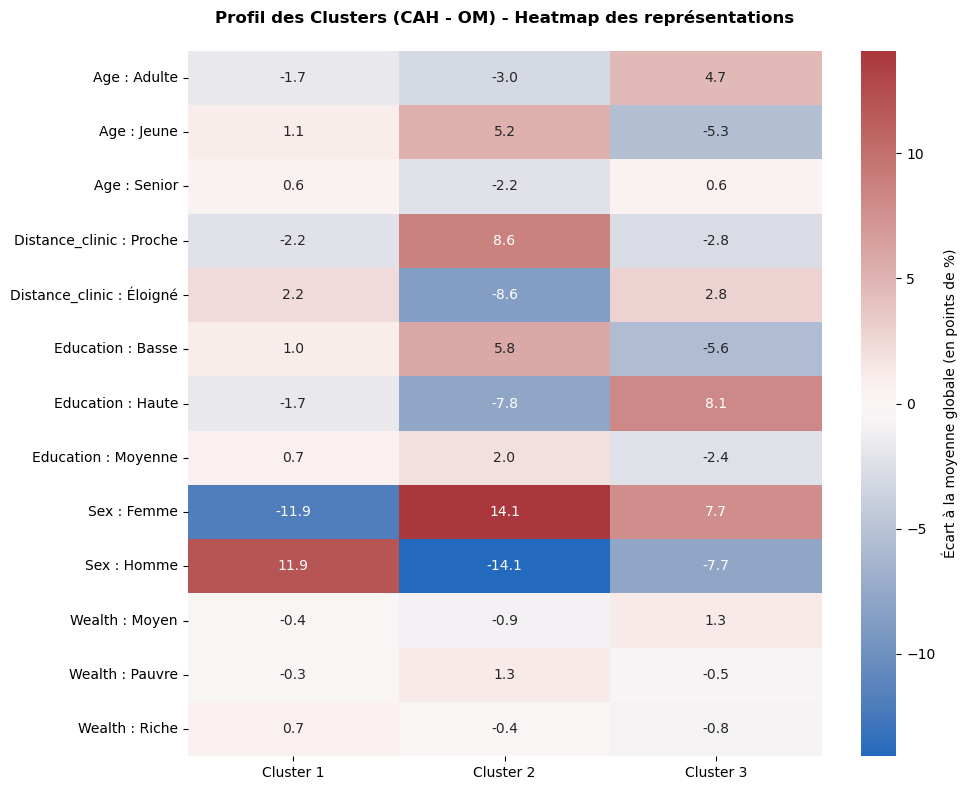

In [67]:
profil_clusters_heatmap(col_stats, clusters_OM, label_var, titre="Profil des Clusters (CAH - OM) - Heatmap des représentations")

Ex : Il y a en moyenne 11,9% de plus d'hommes dans le cluster 1 par rapport à la population globale.
Il y a en moyenne 11,9% de moins de femmes dans le cluster 1 par rapport à la population globale.

Tester d'autres couleurs

* Cluster 1 : 
    * Les hommes, les patients éloignés de la clinique sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Le cluster avec une majorité de patients à l'état de diagnostic durant l'enquête contient plutôt des profils d'hommes assez jeunes qui vivent éloignés de l'hopital.


* Cluster 2 :
    * Les femmes, les patients proches de la clinique, ceux avec un bas degré d'éducation et les jeunes sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes et seniors, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui passent par plusieurs traitements et soins ont plutot un profil de femmes jeunes, avec un bas degré d'éducation (peut-être dû à leur jeunesse) et vivant proches de la clinique (peut-être résidant à l'hopital pour leurs soins).

* Cluster 3 :
    * Les femmes, les patients éloignés de la clinique, les adultes, et ceux avec un haut degré d'éducation sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les jeunes, les patients avec des bas et moyens degrés d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui arrivent rapidement à l'état d'infection contrôlée, sont plutôt des femmes adultes avec un haut degré d'éducation, mais vivant loin de la clinique.

La variable 'Wealth' donnent des écarts compris entre -1 et +1 point pour l'ensemble des clusters. Cela montre que la répartition des niveaux de richesse au sein de chaque trajectoire est assez identique à celle de la population globale. Donc le niveau de vie n'est pas un facteur discriminant dans notre modèle et n'influence pas réellement le parcours de soin du patient.

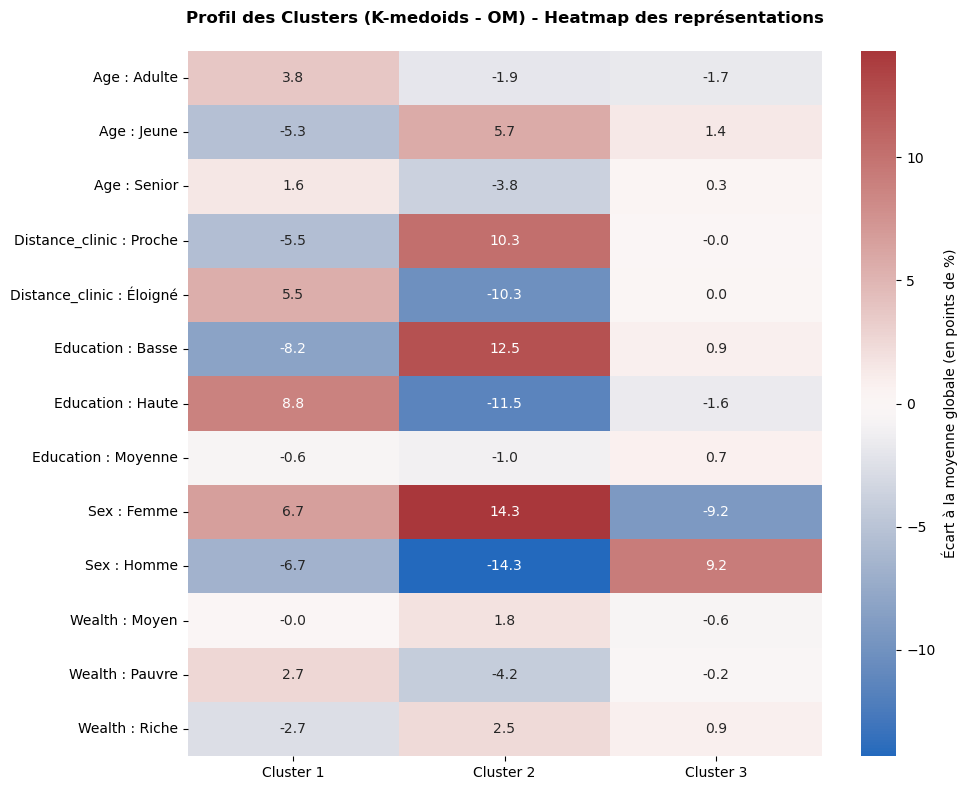

In [68]:
profil_clusters_heatmap(col_stats, kmedoids_labels_OM, label_var, titre="Profil des Clusters (K-medoids - OM) - Heatmap des représentations")

* Cluster 1 :
    * Les femmes, les adultes, les patients éloignés de la clinique, ceux avec un haut degré d'éducation et qui sont plus pauvres sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les jeunes, les patients avec un bas degré d'éducation et un salaire élevé sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui arrivent rapidement à l'état d'infection contrôlée ont plutot un profil de femmes adultes, avec un haut degré d'éducation mais un salaire faible et vivant loins de la clinique.

* Cluster 2 :
    * Les femmes, les patients proches de la clinique, les jeunes, et ceux avec un bas degré d'éducation sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes et seniors, les patients avec des hauts d'éducation, et qui ont un faible salaire sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui passent par plusieurs états de soins et traitement, sont plutôt des femmes jeunes avec un bas degré d'éducation, et vivant proches de la clinique.

* Cluster 3 : 
    * Les hommes, les jeunes sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Le cluster avec une majorité de patients à l'état de diagnostic durant l'enquête contient plutôt des profils d'hommes assez jeunes avec un bas ou moyen degré d'éducation.

La variable 'Wealth' ici a plus d'importance que dans l'autre cas.

On remarque des similarités entre les clusters des 2 méthodes :

* Le groupe "Diagnostic" est dominé par de jeunes hommes (CAH = 1, K-med = 3).
* Le groupe "Soins et Traitements" est dominé par de jeunes femmes, peu éduquées et vivant à proximité (CAH = 2, K-med = 2).
* Le groupe "Infection Contrôlée" est dominé par des femmes adultes, plus éduquées et vivant loin (CAH = 3, K-med = 1).

Mais CAH était plus sensible à la distance, et K-medoids à la richesse.